In [11]:
#####################################################################################################################################
##### This script builds a metabolite-gene network for an input list of metabolites.

##### Data sources:
######### 1. Pathway interactions retrieved from Human1-GEM
######### 2. Metabolite-gene interactions retrieved from IntAct, STITCHdb, BioGRID, chEMBL, UniProt, LINCS (biochemical), L1000 (gene expression)
######### 3. Metabolite-gene interactions retrieved from MetalinksDB (itself retrieved from liana+ package)
#####################################################################################################################################

In [12]:
# import modules and set working directory
import os
import pandas as pd
import numpy as np
import requests
import json
from chembl_webresource_client.new_client import new_client
import networkx as nx
import re
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import xml.etree.ElementTree as ET
import mygene
import matplotlib.pyplot as plt
import seaborn as sns
import logging


# ===== CONFIGURATION - Change output directory here =====
workdir = '/home/borisvdm/Documents/PhD/Lemonite'
OUTPUT_DIR_NAME = 'PKN'  # Change this to use a different output folder
# ========================================================

# Set up paths
OUTPUT_DIR = os.path.join(workdir, OUTPUT_DIR_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Configure logging with absolute path
logging.basicConfig(
    filename=os.path.join(OUTPUT_DIR, 'api_errors.log'),
    level=logging.WARNING,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

hmbd_metabolites_xml = '/home/borisvdm/Documents/PhD/resources/databases/HMDB/hmdb_metabolites.xml'
db_dir = '/home/borisvdm/Documents/PhD/resources/databases'

# Location of resources
BIOGRID_location = '/home/borisvdm/Documents/PhD/resources/databases/BioGRID/BIOGRID-CHEMICALS-4.4.238.chemtab.txt'
STITCH_location = '/home/borisvdm/Documents/PhD/resources/databases/STITCHdb/9606.protein_chemical.links.v5.0.tsv'
uniprot_location = '/home/borisvdm/Documents/PhD/resources/databases/UniProt/uniprot_sprot_human.xml'
# Human-1 GEM downloaded from https://github.com/SysBioChalmers/Human-GEM
GEM_path = '/home/borisvdm/Documents/PhD/resources/models/Human1-GEM/model/Human-GEM.txt'
GEM_metabolites_path = '/home/borisvdm/Documents/PhD/resources/models/Human1-GEM/model/metabolites.tsv'
GEM_reactions_path = '/home/borisvdm/Documents/PhD/resources/models/Human1-GEM/model/reactions.tsv'
GEM_genes_path = '/home/borisvdm/Documents/PhD/resources/models/Human1-GEM/model/genes.tsv'
metalinks_path = '/home/borisvdm/Documents/PhD/resources/databases/metalinks/metalinks.csv'

LINCS_compound_mapping_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/lsp_compound_mapping.csv'
LINCS_target_mapping_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/lsp_target_mapping.csv'
LINCS_target_dictionary_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/lsp_target_dictionary.csv'
LINCS_biochem_agg_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/lsp_biochem_agg.csv'
LINCS_references_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/lsp_references.csv'

# L1000 database files (gene expression signatures)
L1000_gmt_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/L1000/l1000_cp.gmt'
L1000_compounds_location = '/home/borisvdm/Documents/PhD/resources/databases/LINCS/L1000/LINCS_small_molecules.tsv'

pathway_distance = 2

os.chdir(workdir)

In [13]:
# ============================================================================
# CENTRALIZED API RETRY CONFIGURATION
# ============================================================================
import functools
from requests.exceptions import Timeout, ConnectionError, RequestException

# Configure retry behavior per database
# Adjust these values to balance speed vs. API reliability
API_RETRY_CONFIG = {
    'UniProtKB': {
        'max_retries': 10,
        'backoff_factor': 3,  # Wait time multiplier (exponential backoff)
        'timeout': 30,  # Request timeout in seconds
        'max_workers': 3,  # Concurrent threads (lower = gentler on API)
        'pause_after': 50,  # Pause every N requests
        'pause_duration': 15  # Pause duration in seconds
    },
    'IntAct': {
        'max_retries': 10,
        'backoff_factor': 2,
        'timeout': 25,
        'max_workers': 4,
        'pause_after': 75,
        'pause_duration': 10
    },
    'chEMBL': {
        'max_retries': 10,
        'backoff_factor': 2,
        'timeout': 25,
        'max_workers': 5,
        'pause_after': 100,
        'pause_duration': 8
    },
    'ChEMBL_Mapping': {
        'max_retries': 10,
        'backoff_factor': 2,
        'timeout': 25,
        'max_workers': 5,
        'pause_after': 100,
        'pause_duration': 8
    }
}

# ============================================================================
# UNIVERSAL RETRY DECORATOR
# ============================================================================

def retry_api_call(db_name='default'):
    """
    Decorator that adds intelligent retry logic to any API function.
    
    Features:
    - Exponential backoff for failed requests
    - Extra delays for connection timeouts
    - Database-specific retry configurations
    - Detailed logging of retry attempts
    
    Parameters:
    -----------
    db_name : str
        Name of database to get specific retry config
    
    Returns:
    --------
    Decorated function with retry logic
    """
    config = API_RETRY_CONFIG.get(db_name, {
        'max_retries': 5,
        'backoff_factor': 2,
        'timeout': 15
    })
    
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            max_retries = config['max_retries']
            backoff_factor = config['backoff_factor']
            
            for attempt in range(max_retries):
                try:
                    return func(*args, **kwargs)
                
                except (Timeout, ConnectionError) as e:
                    # Connection issues - use extra exponential backoff
                    wait_time = backoff_factor ** (attempt + 2)
                    error_type = "Connection timeout" if isinstance(e, Timeout) else "Connection error"
                    logging.warning(
                        f"[{db_name}] {error_type} in {func.__name__} "
                        f"(attempt {attempt + 1}/{max_retries}): {str(e)[:100]}. "
                        f"Retrying in {wait_time}s..."
                    )
                    if attempt < max_retries - 1:
                        time.sleep(wait_time)
                
                except RequestException as e:
                    # Other request errors - standard backoff
                    wait_time = backoff_factor ** attempt
                    logging.warning(
                        f"[{db_name}] Request error in {func.__name__} "
                        f"(attempt {attempt + 1}/{max_retries}): {str(e)[:100]}. "
                        f"Retrying in {wait_time}s..."
                    )
                    if attempt < max_retries - 1:
                        time.sleep(wait_time)
                
                except Exception as e:
                    # Unexpected errors - standard backoff
                    wait_time = backoff_factor ** attempt
                    logging.warning(
                        f"[{db_name}] Unexpected error in {func.__name__} "
                        f"(attempt {attempt + 1}/{max_retries}): {str(e)[:100]}. "
                        f"Retrying in {wait_time}s..."
                    )
                    if attempt < max_retries - 1:
                        time.sleep(wait_time)
            
            # All retries exhausted
            logging.error(f"[{db_name}] Failed to execute {func.__name__} after {max_retries} attempts")
            return 'none'  # Return 'none' for failed metabolite lookups
        
        return wrapper
    return decorator

print("✅ API retry configuration loaded")
print(f"   Configured databases: {', '.join(API_RETRY_CONFIG.keys())}")

✅ API retry configuration loaded
   Configured databases: UniProtKB, IntAct, chEMBL, ChEMBL_Mapping


In [14]:
import pandas as pd
import numpy as np
import time
import os
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# --- Use OUTPUT_DIR from first cell ---
# OUTPUT_DIR is already defined in the first cell as os.path.join(workdir, OUTPUT_DIR_NAME)
# No need to redefine it here

# --- Logging Setup ---
# Note: This will override the previous logging config
logging.basicConfig(
    filename=os.path.join(OUTPUT_DIR, 'pipeline_progress.log'),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True  # Override previous config
)

# --- Output file paths (all use OUTPUT_DIR from first cell) ---
OUTPUT_FILE_FINAL = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_gene_interactions.csv') 


# Individual database output files
DB_OUTPUT_FILES = {
    'IntAct': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_IntAct_processed.csv'),
    'UniProtKB': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_UniProtKB_processed.csv'),
    'chEMBL': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_chEMBL_processed.csv'),
    'STITCH': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_STITCH_processed.csv'),
    'BioGRID': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_BioGRID_processed.csv'),
    'LINCS': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_LINCS_processed.csv'),
    'L1000': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_L1000_processed.csv'),
    'Human1_GEM_dist1': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_Human1_GEM_dist1_processed.csv'),
    'Human1_GEM_dist2': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_Human1_GEM_dist2_processed.csv'),
    'MetalinksDB': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_MetalinksDB_processed.csv')
}

URL_FILES = {
    'UniProtKB': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_UniProtKB_links.csv'),
    'IntAct': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_IntAct_links.csv'),
    'chEMBL': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_chEMBL_links.csv'),
    'STITCH': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_STITCH_links.csv'),
    'BioGRID': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_BioGRID_links.csv'),
    'LINCS': os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_LINCS_links.csv')
}

CHUNK_SIZE = 800
PAUSE_BETWEEN_CHUNKS = 8

# --- Ensure output directory exists ---
os.makedirs(OUTPUT_DIR, exist_ok=True)

def apply_function_with_multithreading(df_subset, query_column, db_name, interaction_function, pause_after=None):
    """
    Apply interaction function to a subset of metabolites using multithreading.
    Uses database-specific configuration from API_RETRY_CONFIG.
    """
    # Get database-specific configuration or use defaults
    config = API_RETRY_CONFIG.get(db_name, {})
    max_workers = config.get('max_workers', 6)
    if pause_after is None:
        pause_after = config.get('pause_after', 100)
    pause_duration = config.get('pause_duration', 8)
    
    results = {}
    error_ids = []
    request_count = 0

    logging.info(f"[{db_name}] Using {max_workers} workers, pausing every {pause_after} requests for {pause_duration}s")
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(interaction_function, row): index for index, row in df_subset[query_column].items()}
        logging.info(f"Submitted {len(futures)} requests for {db_name}.")

        for future in as_completed(futures):
            index = futures[future]
            try:
                result = future.result()
                results[index] = result
            except Exception as e:
                logging.warning(f"Error in {db_name} at index {index}: {e}")
                error_ids.append(index)
                results[index] = 'error_occurred'

            request_count += 1
            if request_count % pause_after == 0:
                logging.info(f"Processed {request_count} requests for {db_name}, pausing for {pause_duration}s...")
                time.sleep(pause_duration)

    # Log summary
    success_count = len(results) - len(error_ids)
    logging.info(f"{db_name}: {success_count} successful, {len(error_ids)} errors out of {len(results)} total")
    
    return results

def save_url_data(db_name):
    """Save URL data to separate CSV files for a specific database"""
    if db_name in globals()['url_data_storage']:
        url_data = globals()['url_data_storage'][db_name]
        if url_data:  # Only save if there's data
            url_df = pd.DataFrame(url_data)
            url_df.to_csv(URL_FILES[db_name], index=False, sep='\t')
            logging.info(f"Saved {len(url_data)} URL records for {db_name}")

def is_processed(value):
    """
    Check if a metabolite has been processed for a given database
    Returns True if processed (has 'none', 'error_occurred', or actual data)
    Returns False if still needs processing (is NaN or empty string)
    """
    return pd.notna(value) and value != '' and value != ' '

def process_single_database(df_input, db_name, column, function):
    """
    Process a single database independently and save to its own file
    
    Parameters:
    - df_input: Input dataframe with metabolite annotations
    - db_name: Name of the database ('IntAct', 'UniProtKB', or 'chEMBL')
    - column: Column name to use as input for the function
    - function: The interaction retrieval function to use
    
    Returns:
    - DataFrame with results for this database
    """
    logging.info(f"=" * 80)
    logging.info(f"Starting processing for {db_name}")
    logging.info(f"=" * 80)
    
    # Initialize URL storage for this database
    if 'url_data_storage' not in globals():
        globals()['url_data_storage'] = {}
    globals()['url_data_storage'][db_name] = []
    
    # Check if output file exists (resume capability)
    output_file = DB_OUTPUT_FILES[db_name]
    
    if os.path.exists(output_file):
        df_existing = pd.read_csv(output_file, sep='\t', low_memory=False, na_values=['', ' ', 'NA'])
        logging.info(f"Found existing {db_name} file with {len(df_existing)} rows")
        
        # Merge existing results with input dataframe to preserve indices
        df_work = df_input[['HMDB', column]].copy()
        df_work = df_work.merge(df_existing[['HMDB', db_name]], on='HMDB', how='left', suffixes=('', '_existing'))
        
        # Use existing results where available
        if f'{db_name}_existing' in df_work.columns:
            df_work[db_name] = df_work[f'{db_name}_existing']
            df_work.drop(columns=[f'{db_name}_existing'], inplace=True)
        elif db_name not in df_work.columns:
            df_work[db_name] = np.nan
        
        processed_count = df_work[db_name].apply(is_processed).sum()
        logging.info(f"Resuming {db_name}: {processed_count} already processed, {len(df_work) - processed_count} remaining")
    else:
        # Start fresh - create working dataframe
        df_work = df_input[['HMDB', column]].copy()
        df_work[db_name] = np.nan
        logging.info(f"Starting {db_name} from scratch with {len(df_work)} rows")
    
    # Chunk-wise processing
    total_chunks = (len(df_work) - 1) // CHUNK_SIZE + 1
    
    # Find first unprocessed chunk to start from (optimization for resume)
    first_unprocessed_chunk = 0
    if os.path.exists(output_file):
        for chunk_num in range(total_chunks):
            start = chunk_num * CHUNK_SIZE
            end = min(start + CHUNK_SIZE, len(df_work))
            chunk_data = df_work.iloc[start:end]
            
            # Check if chunk has any unprocessed metabolites
            unprocessed_count = (~chunk_data[db_name].apply(is_processed)).sum()
            if unprocessed_count > 0:
                first_unprocessed_chunk = chunk_num
                logging.info(f"[{db_name}] Fast-forwarding to first unprocessed chunk: {chunk_num + 1}/{total_chunks}")
                break
    
    progress_bar = tqdm(total=total_chunks, desc=f"Processing {db_name}", unit="chunk", initial=first_unprocessed_chunk)
    
    for chunk_num in range(first_unprocessed_chunk, total_chunks):
        start = chunk_num * CHUNK_SIZE
        end = min(start + CHUNK_SIZE, len(df_work))
        chunk_idx = range(start, end)
        
        logging.info(f"[{db_name}] Processing chunk {chunk_num + 1}/{total_chunks} (rows {start}–{end})")
        
        # Get chunk data
        chunk_data = df_work.iloc[start:end]
        
        # Find unprocessed metabolites
        unprocessed_mask = ~chunk_data[db_name].apply(is_processed)
        has_identifier = chunk_data[column].notna()
        no_identifier = chunk_data[column].isna()
        
        # Process metabolites WITH identifiers
        to_process_mask = unprocessed_mask & has_identifier
        
        # Mark metabolites WITHOUT identifiers as 'none' (can't search without identifier)
        to_mark_none_mask = unprocessed_mask & no_identifier
        if to_mark_none_mask.any():
            none_indices = chunk_data[to_mark_none_mask].index
            for idx in none_indices:
                df_work.loc[idx, db_name] = 'none'
            logging.info(f"[{db_name}] Marked {len(none_indices)} metabolites without {column} as 'none'")
        
        if to_process_mask.any():
            metabolites_to_process = chunk_data[to_process_mask]
            
            logging.info(f"[{db_name}] Processing {len(metabolites_to_process)} unprocessed metabolites")
            
            # Process metabolites
            results = apply_function_with_multithreading(
                metabolites_to_process, column, db_name, function
            )
            
            # Map results back
            for idx, result in results.items():
                df_work.loc[idx, db_name] = result
            
            # Save progress
            save_url_data(db_name)
            df_work.to_csv(output_file, index=False, sep='\t')
            logging.info(f"[{db_name}] Saved progress after chunk {chunk_num}")
            time.sleep(PAUSE_BETWEEN_CHUNKS)
        else:
            logging.info(f"[{db_name}] Chunk {chunk_num} already processed, skipping")
        
        progress_bar.update(1)
    
    progress_bar.close()
    
    # Final save
    save_url_data(db_name)
    df_work.to_csv(output_file, index=False, sep='\t')
    logging.info(f"[{db_name}] Processing complete! Results saved to {output_file}")
    
    return df_work

def merge_database_results(df_base):
    """
    Merge results from all database-specific files into a single dataframe
    
    Parameters:
    - df_base: Base dataframe with all metabolite annotations
    
    Returns:
    - Merged dataframe with all interaction data
    """
    logging.info("=" * 80)
    logging.info("Merging results from all databases")
    logging.info("=" * 80)
    
    df_merged = df_base.copy()
    
    # Add columns for each database if they don't exist
    for db_name in ['IntAct', 'UniProtKB', 'chEMBL', 'LINCS', 'STITCH', 'BioGRID', 
                     'Human1_GEM_dist1', 'Human1_GEM_dist2', 'MetalinksDB']:
        if db_name not in df_merged.columns:
            df_merged[db_name] = np.nan
    
    # Merge each database file
    for db_name, file_path in DB_OUTPUT_FILES.items():
        if os.path.exists(file_path):
            logging.info(f"Merging {db_name} from {file_path}")
            df_db = pd.read_csv(file_path, sep='\t', low_memory=False)
            
            # Merge on HMDB ID
            df_merged = df_merged.merge(
                df_db[['HMDB', db_name]], 
                on='HMDB', 
                how='left', 
                suffixes=('', f'_{db_name}')
            )
            
            # Update the column (prefer the newly loaded data)
            if f'{db_name}_{db_name}' in df_merged.columns:
                df_merged[db_name] = df_merged[f'{db_name}_{db_name}'].fillna(df_merged[db_name])
                df_merged.drop(columns=[f'{db_name}_{db_name}'], inplace=True)
            
            logging.info(f"Merged {db_name}: {df_merged[db_name].notna().sum()} metabolites have data")
        else:
            logging.warning(f"File not found: {file_path}. Skipping {db_name}")
    
    # Handle legacy column name 'BioGRID_metabolite' -> rename to 'BioGRID'
    if 'BioGRID_metabolite' in df_merged.columns:
        if 'BioGRID' not in df_merged.columns:
            df_merged.rename(columns={'BioGRID_metabolite': 'BioGRID'}, inplace=True)
            logging.info("Renamed 'BioGRID_metabolite' column to 'BioGRID'")
        else:
            # If both exist, merge them and drop the old one
            df_merged['BioGRID'] = df_merged['BioGRID'].fillna(df_merged['BioGRID_metabolite'])
            df_merged.drop(columns=['BioGRID_metabolite'], inplace=True)
            logging.info("Merged 'BioGRID_metabolite' into 'BioGRID' column")
    
    # Save merged results
    df_merged.to_csv(OUTPUT_FILE_FINAL, index=False, sep='\t')
    logging.info(f"Merged results saved to {OUTPUT_FILE_FINAL}")
    
    return df_merged

# Parse HMDB to retrieve human metabolites

In [15]:
import xml.etree.ElementTree as ET
import pandas as pd


def parseHMDB():

    # Parse the XML file incrementally
    context = ET.iterparse(hmbd_metabolites_xml, events=('end',))

    # Namespaces to handle XML tags with namespaces
    ns = {'hmdb': 'http://www.hmdb.ca'}

    # Initialize a list to store parsed data
    data = []

    metabolite_count = 0

    # Iterate over elements as they close
    for event, elem in context:

        
        if elem.tag == '{http://www.hmdb.ca}metabolite':

            # Extract the required data
            name = elem.find('hmdb:name', ns).text
            hmdb_id = elem.find('hmdb:accession', ns).text
            iupac_name = elem.find('hmdb:iupac_name', ns).text
            smiles = elem.find('hmdb:smiles', ns).text
            inchikey = elem.find('hmdb:inchikey', ns).text

            chebi_id = elem.find('hmdb:chebi_id', ns).text if elem.find('hmdb:chebi_id', ns) is not None else None
            kegg_id = elem.find('hmdb:kegg_id', ns).text if elem.find('hmdb:kegg_id', ns) is not None else None
            pdb_id = elem.find('hmdb:pdb_id', ns).text if elem.find('hmdb:pdb_id', ns) is not None else None
            pubchem_id = elem.find('hmdb:pubchem_compound_id', ns).text if elem.find('hmdb:pubchem_compound_id', ns) is not None else None

            # Also extract molecule super_class and sub_class
            super_class = elem.find('hmdb:taxonomy/hmdb:super_class', ns).text if elem.find('hmdb:taxonomy/hmdb:super_class', ns) is not None else None
            sub_class = elem.find('hmdb:taxonomy/hmdb:sub_class', ns).text if elem.find('hmdb:taxonomy/hmdb:sub_class', ns) is not None else None
            kingdom = elem.find('hmdb:taxonomy/hmdb:kingdom', ns).text if elem.find('hmdb:taxonomy/hmdb:kingdom', ns) is not None else None

            # Append the extracted data to the list
            data.append({
                'Name': name,
                'HMDB': hmdb_id,
                'ChEBI': chebi_id,
                'KEGG': kegg_id,
                'PubChem': pubchem_id,
                'IUPAC_Name': iupac_name,
                'SMILES': smiles,
                'InChIKey': inchikey,
                'PDB_ID': pdb_id,
                'Kingdom': kingdom,
                'Super_Class': super_class,
                'Sub_Class': sub_class

            })

            # Clear the element from memory
            elem.clear()

            metabolite_count += 1

    # Convert the list of dictionaries to a DataFrame
    df = pd.DataFrame(data)

    print(df)

    # save dataframe in db_dir
    #df.to_csv(os.path.join(db_dir, 'HMDB', 'metabolites_annotated.csv'), index=False, sep='\t')
    #df.to_csv('/home/borisvdm/Documents/PhD/Lemonite/PKN/HMDB_metabolites_annotated.csv', index=False, sep='\t')
    df.to_csv(os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated.csv'), index=False, sep='\t')
    
    return df


df = parseHMDB()

                              Name         HMDB  ChEBI    KEGG PubChem  \
0                1-Methylhistidine  HMDB0000001  50599  C01152   92105   
1               1,3-Diaminopropane  HMDB0000002  15725  C00986     428   
2               2-Ketobutyric acid  HMDB0000005  30831  C00109      58   
3            2-Hydroxybutyric acid  HMDB0000008  50613  C05984  440864   
4                 2-Methoxyestrone  HMDB0000010   1189  C05299  440624   
...                            ...          ...    ...     ...     ...   
217915         Nordeoxycholic acid  HMDB0304947   None    None  314374   
217916  3-Oxo-5beta-cholanoic acid  HMDB0304950   None    None  543448   
217917        Glycerol 1-myristate  HMDB0304951  75562    None   79050   
217918       O-Phenolsulfonic acid  HMDB0304953  71049    None   11867   
217919                   d-Fucitol  HMDB0304954   None    None  445724   

                                               IUPAC_Name  \
0       (2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)

In [16]:
df = pd.read_csv(os.path.join(db_dir, 'HMDB', 'metabolites_annotated.csv'), sep=',')
#pd.read_csv('/home/boris/Documents/PhD/resources/databases/HMDB/metabolites_annotated.csv', sep ='\t')
metabolite_count = df.shape[0]
df

,Name,HMDB,ChEBI,KEGG,PubChem,IUPAC_Name,SMILES,InChIKey,PDB_ID,Kingdom,Super_Class,Sub_Class
0,1-Methylhistidine,HMDB0000001,50599.0,C01152,92105.0,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)prop...,CN1C=NC(C[C@H](N)C(O)=O)=C1,BRMWTNUJHUMWMS-LURJTMIESA-N,NaN,Organic acids and derivatives,Organic acids and derivatives,"Amino acids, peptides, and analogues"
1,"1,3-Diaminopropane",HMDB0000002,15725.0,C00986,428.0,"propane-1,3-diamine",NCCCN,XFNJVJPLKCPIBV-UHFFFAOYSA-N,NaN,Organic nitrogen compounds,Organic nitrogen compounds,Amines
2,2-Ketobutyric acid,HMDB0000005,30831.0,C00109,58.0,2-oxobutanoic acid,CCC(=O)C(O)=O,TYEYBOSBBBHJIV-UHFFFAOYSA-N,NaN,Organic acids and derivatives,Organic acids and derivatives,Short-chain keto acids and derivatives
3,2-Hydroxybutyric acid,HMDB0000008,50613.0,C05984,440864.0,(2S)-2-hydroxybutanoic acid,CC[C@H](O)C(O)=O,AFENDNXGAFYKQO-VKHMYHEASA-N,NaN,Organic acids and derivatives,Organic acids and derivatives,Alpha hydroxy acids and derivatives
4,2-Methoxyestrone,HMDB0000010,1189.0,C05299,440624.0,"(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-methyl...",[H][C@@]12CCC(=O)[C@@]1(C)CC[C@]1([H])C3=C(CC[...,WHEUWNKSCXYKBU-QPWUGHHJSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,Estrane steroids
...,...,...,...,...,...,...,...,...,...,...,...,...
217915,Nordeoxycholic acid,HMDB0304947,NaN,NaN,314374.0,"3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8.7....",CC(CC(O)=O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C,PLRQOCVIINWCFA-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,"Bile acids, alcohols and derivatives"
217916,3-Oxo-5beta-cholanoic acid,HMDB0304950,NaN,NaN,543448.0,"4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,7}...",CC(CCC(O)=O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C,KIQFUORWRVZTHT-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,"Bile acids, alcohols and derivatives"
217917,Glycerol 1-myristate,HMDB0304951,75562.0,NaN,79050.0,"2,3-dihydroxypropyl tetradecanoate",CCCCCCCCCCCCCC(=O)OCC(O)CO,DCBSHORRWZKAKO-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,Lipids and lipid-like molecules,Monoradylglycerols
217918,O-Phenolsulfonic acid,HMDB0304953,71049.0,NaN,11867.0,2-hydroxybenzene-1-sulfonic acid,OC1=CC=CC=C1S(O)(=O)=O,IULJSGIJJZZUMF-UHFFFAOYSA-N,NaN,Benzenoids,Benzenoids,Benzenesulfonic acids and derivatives


In [17]:
# Print statistics, how many unique metabolites and id's?
print(f'Parsed {metabolite_count} metabolites from hmdb database')
print(f'Unique HMDB ids: {df.HMDB.nunique()}')
print(f'Unique ChEBI ids: {df.ChEBI.nunique()}')
print(f'Unique KEGG ids: {df.KEGG.nunique()}')
print(f'Unique PubChem ids: {df.PubChem.nunique()}')
print(f'Unique InChIKeys: {df.InChIKey.nunique()}')
print(f'Unique SMILES: {df.SMILES.nunique()}')
print(f'Unique IUPAC names: {df.IUPAC_Name.nunique()}')
print(f'Unique PDB ids: {df.PDB_ID.nunique()}')

Parsed 217920 metabolites from hmdb database
Unique HMDB ids: 217920
Unique ChEBI ids: 13562
Unique KEGG ids: 5908
Unique PubChem ids: 103682
Unique InChIKeys: 217895
Unique SMILES: 217460
Unique IUPAC names: 216741
Unique PDB ids: 520


In [18]:
os.getcwd()

'/home/borisvdm/Documents/PhD/Lemonite'

/tmp/ipykernel_47939/2465390867.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x='ID', y='Count', palette='dark')


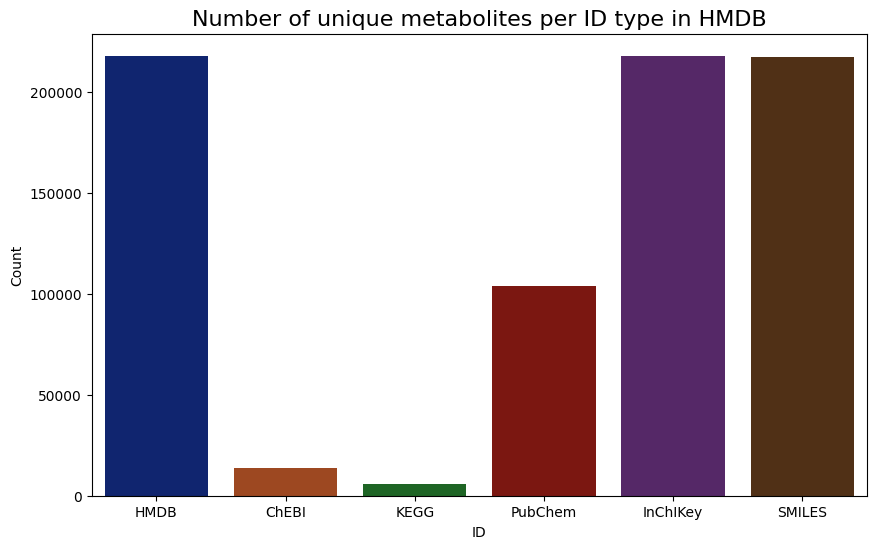

In [19]:
# Create a barplot for that shows the number of metabolites per ID
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dataframe with the counts
counts = pd.DataFrame({
    'ID': ['HMDB', 'ChEBI', 'KEGG', 'PubChem', 'InChIKey', 'SMILES'],
    'Count': [df.HMDB.nunique(), df.ChEBI.nunique(), df.KEGG.nunique(), df.PubChem.nunique(), df.InChIKey.nunique(), df.SMILES.nunique()]
})

# Plot the counts
plt.figure(figsize=(10, 6))
sns.barplot(data=counts, x='ID', y='Count', palette='dark')
plt.title('Number of unique metabolites per ID type in HMDB', fontsize=16)

# Save the plot (using OUTPUT_DIR from first cell)
figures_dir = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'HMDB_unique_metabolites_per_id.png'), dpi=600)

plt.show()

In [20]:
# get columns Name and iupac_name from df as refmet_annotated_1_2
refmet_annotated_1_2 = df[['Name', 'IUPAC_Name', 'HMDB']]
refmet_annotated_1_2 = refmet_annotated_1_2.drop_duplicates()
refmet_annotated_1_2

,Name,IUPAC_Name,HMDB
0,1-Methylhistidine,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)prop...,HMDB0000001
1,"1,3-Diaminopropane","propane-1,3-diamine",HMDB0000002
2,2-Ketobutyric acid,2-oxobutanoic acid,HMDB0000005
3,2-Hydroxybutyric acid,(2S)-2-hydroxybutanoic acid,HMDB0000008
4,2-Methoxyestrone,"(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-methyl...",HMDB0000010
...,...,...,...
217915,Nordeoxycholic acid,"3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8.7....",HMDB0304947
217916,3-Oxo-5beta-cholanoic acid,"4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,7}...",HMDB0304950
217917,Glycerol 1-myristate,"2,3-dihydroxypropyl tetradecanoate",HMDB0304951
217918,O-Phenolsulfonic acid,2-hydroxybenzene-1-sulfonic acid,HMDB0304953


### Add canonical SMILES id

In [21]:
# Add INCHIKEY to the dataframe
from rdkit import Chem

def smiles_to_canonical(smiles):
    try:
        if smiles != 'NA':
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                canonical = Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
                #print(f'Converted {smiles} to {canonical}')
                return canonical
        else:
            return np.nan
    except Exception as e:
        #print(f"Error converting SMILES to canonical SMILES: {e}")
        pass
    return np.nan

smiles = "CC(=O)Oc1ccccc1C(=O)O"
canonical_smiles = smiles_to_canonical(smiles)
print("Canonical SMILES:", canonical_smiles)

Canonical SMILES: CC(=O)Oc1ccccc1C(=O)O


In [23]:
# Add canonical SMILES
df["Canonical_smiles"] = df["SMILES"].apply(smiles_to_canonical)
print(df[df['Canonical_smiles'] != 'NA'].shape[0], 'out of', df.shape[0], 'annotated with Canonical SMILES')

df.to_csv('/home/borisvdm/Documents/PhD/Lemonite/PKN/HMDB_metabolites_annotated.csv', index=False, sep='\t')

[15:17:02] Explicit valence for atom # 1 N, 3, is greater than permitted
[15:17:02] Explicit valence for atom # 0 P, 11, is greater than permitted
[15:17:05] Explicit valence for atom # 21 N, 4, is greater than permitted
[15:17:05] Explicit valence for atom # 1 Cl, 4, is greater than permitted
[15:17:12] WARNING: not removing hydrogen atom without neighbors
[15:17:12] Explicit valence for atom # 6 C, 5, is greater than permitted
[15:18:08] Explicit valence for atom # 18 S, 7, is greater than permitted
[15:18:10] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[15:18:10] SMILES Parse Error: check for mistakes around position 76:
[15:18:10] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C
[15:18:10] ~~~~~~~~~~~~~~~~~~~~^
[15:18:10] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=

217920 out of 217920 annotated with Canonical SMILES


### Add chEMBL ID

In [20]:
# PREPROCESSING STEP: Map all canonical SMILES to ChEMBL IDs
# This mapping will be reused by both chEMBL and LINCS functions

import os
from tqdm import tqdm

# Use OUTPUT_DIR from the first cell configuration
CHEMBL_MAPPING_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_ChEMBL_mapping.csv')

@retry_api_call(db_name='ChEMBL_Mapping')
def get_chembl_id_from_smiles(canonical_smiles):
    """
    Get ChEMBL ID from canonical SMILES string.
    Returns ChEMBL ID or 'none' if not found.
    """
    if pd.isna(canonical_smiles) or canonical_smiles == 'NA' or canonical_smiles == '':
        return 'none'
    
    molecule = new_client.molecule
    mol_data = molecule.filter(molecule_structures__canonical_smiles=canonical_smiles)
    mol_data = list(mol_data)
    
    if not mol_data:
        return 'none'
    
    return mol_data[0]['molecule_chembl_id']

# Load existing mapping if available (for resume capability)
if os.path.exists(CHEMBL_MAPPING_FILE):
    print(f"Loading existing ChEMBL mapping from {CHEMBL_MAPPING_FILE}")
    chembl_mapping = pd.read_csv(CHEMBL_MAPPING_FILE, sep='\t')
    df = df.merge(chembl_mapping[['HMDB', 'ChEMBL_id']], on='HMDB', how='left', suffixes=('', '_mapped'))
    
    # Use mapped values if available
    if 'ChEMBL_id_mapped' in df.columns:
        df['ChEMBL_id'] = df['ChEMBL_id_mapped'].fillna(df.get('ChEMBL_id', 'none'))
        df.drop('ChEMBL_id_mapped', axis=1, inplace=True)
    
    print(f"Loaded {chembl_mapping['ChEMBL_id'].notna().sum()} existing ChEMBL mappings")
else:
    print("No existing ChEMBL mapping found, will create new mapping")
    df['ChEMBL_id'] = 'none'

# Identify metabolites that need mapping
needs_mapping = df['ChEMBL_id'].isna() | (df['ChEMBL_id'] == 'none')
to_map = df[needs_mapping & df['Canonical_smiles'].notna()].copy()

print(f"\nChEMBL Mapping Status:")
print(f"  Total metabolites: {len(df)}")
print(f"  Already mapped: {(~needs_mapping).sum()}")
print(f"  Need mapping: {len(to_map)}")

if len(to_map) > 0:
    print(f"\nMapping {len(to_map)} SMILES to ChEMBL IDs...")
    print("This is a one-time operation that will speed up both chEMBL and LINCS queries")
    print("="*80)
    
    # Use multithreading for faster mapping
    chembl_ids = apply_function_with_multithreading(
        df_subset=to_map, 
        query_column='Canonical_smiles',
        db_name='ChEMBL_Mapping',
        interaction_function=get_chembl_id_from_smiles
    )
    
    # Update df with new mappings
    df.loc[to_map.index, 'ChEMBL_id'] = chembl_ids
    
    # Save mapping for future use
    mapping_df = df[['HMDB', 'Canonical_smiles', 'ChEMBL_id']].copy()
    mapping_df.to_csv(CHEMBL_MAPPING_FILE, index=False, sep='\t')
    
    mapped_count = (df['ChEMBL_id'] != 'none').sum()
    print(f"\nChEMBL mapping complete!")
    print(f"  Successfully mapped: {mapped_count} metabolites")
    print(f"  Mapping saved to: {CHEMBL_MAPPING_FILE}")
else:
    print("\nAll metabolites already mapped, skipping ChEMBL API calls")

print("="*80)

Loading existing ChEMBL mapping from /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_ChEMBL_mapping.csv
Loaded 217920 existing ChEMBL mappings

ChEMBL Mapping Status:
  Total metabolites: 217920
  Already mapped: 11358
  Need mapping: 206530

Mapping 206530 SMILES to ChEMBL IDs...
This is a one-time operation that will speed up both chEMBL and LINCS queries


KeyboardInterrupt: 

# Retrieve database interactions

### BioGRID

In [ ]:
BIOGRID = pd.read_csv(BIOGRID_location, sep='\t')
# Drop rows in which 'InChiKey' does not match one of the InChiKeys in df
BIOGRID = BIOGRID[BIOGRID['InChIKey'].isin(df['InChIKey'])]

# print column names
print(BIOGRID.columns)

# print(BIOGRID.columns) # 1708 interactions retained

BIOGRID_dict = {}

for index, row in BIOGRID.iterrows():
    if row['InChIKey'] in BIOGRID_dict:
        BIOGRID_dict[row['InChIKey']].append(row['Official Symbol'])
    else:
        BIOGRID_dict[row['InChIKey']] = [row['Official Symbol']]
# remove duplicates
for key in BIOGRID_dict:
    BIOGRID_dict[key] = list(set(BIOGRID_dict[key]))

print(f'BIOGRID dictionary contains interactions for {len(BIOGRID_dict)} metabolites')


Index(['#BioGRID Chemical Interaction ID', 'BioGRID Gene ID', 'Entrez Gene ID',
       'Systematic Name', 'Official Symbol', 'Synonyms', 'Organism ID',
       'Organism', 'Action', 'Interaction Type', 'Author', 'Pubmed ID',
       'BioGRID Publication ID', 'BioGRID Chemical ID', 'Chemical Name',
       'Chemical Synonyms', 'Chemical Brands', 'Chemical Source',
       'Chemical Source ID', 'Molecular Formula', 'Chemical Type', 'ATC Codes',
       'CAS Number', 'Curated By', 'Method', 'Method Description',
       'Related BioGRID Gene ID', 'Related Entrez Gene ID',
       'Related Systematic Name', 'Related Official Symbol',
       'Related Synonyms', 'Related Organism ID', 'Related Organism',
       'Related Type', 'Notes', 'InChIKey'],
      dtype='object')
BIOGRID dictionary contains interactions for 1672 metabolites
BIOGRID dictionary contains interactions for 1672 metabolites


In [ ]:
# link to original BIOGRID database
def biogrid_url(InChIKey):
    # Find the first row where the InChIKey matches
    match = BIOGRID[BIOGRID['InChIKey'] == InChIKey]

    if not match.empty:
        chemical_id = match.iloc[0, 13]  # Column 14 = index 13
        chemical_name = match.iloc[0, 14]  # Column 15 = index 14 
        url = f"https://thebiogrid.org/chemical/{chemical_id}/{chemical_name}.html"
        return url
    else:
        return f"No match found for InChIKey: {InChIKey}"

    
#testing of the function
print(biogrid_url('4-Methyl-Histidine'))
print(biogrid_url('abc'))

No match found for InChIKey: 4-Methyl-Histidine
No match found for InChIKey: abc


In [ ]:
rows = []  # This will store the final rows with one BioGRID metabolite per row

for index, row in df.iterrows():
    key = row['InChIKey']
    if pd.notna(key) and key in BIOGRID_dict:
        metabolites = BIOGRID_dict[key]  # list of metabolites (gene symbols or proteins)
        url = biogrid_url(key)
        for metabolite in metabolites:
            rows.append({
                'HMDB': row['HMDB'],
                'BioGRID': metabolite,
                'url': url
            })
    if index % 50000 == 0:
        print(f'Processed {index} metabolites')

# Create new DataFrame
expanded_df = pd.DataFrame(rows)

print(expanded_df.shape[0], 'BioGRID interactions in total')

# Save to CSV (using OUTPUT_DIR from first cell)
expanded_df.to_csv(os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_BioGRID_links.csv'),
                   index=False, columns=['HMDB', 'BioGRID', 'url'], sep='\t')

Processed 0 metabolites
Processed 50000 metabolites
Processed 50000 metabolites
Processed 100000 metabolites
Processed 100000 metabolites
Processed 150000 metabolites
Processed 150000 metabolites
Processed 200000 metabolites
Processed 200000 metabolites
6359 BioGRID interactions in total
6359 BioGRID interactions in total


### STITCHd

In [1]:
stitch = pd.read_csv(STITCH_location, sep='\t')
# Remove all non-digit characters from chemical column
stitch['chemical'] = stitch['chemical'].str.replace(r'\D', '', regex=True)
print(f'STITCHdb contains {stitch.shape[0]} interactions involving {stitch["chemical"].nunique()} metabolites and {stitch["protein"].nunique()} proteins')
# Remove '9606.' from protein column
stitch['protein'] = stitch['protein'].str.replace('9606.', '', regex=False)

NameError: name 'pd' is not defined

In [ ]:
print(stitch)

          chemical          protein  combined_score
0         91758680  ENSP00000257254             279
1         91758680  ENSP00000302120             154
2         91758408  ENSP00000006777             225
3         91758408  ENSP00000056217             178
4         91758408  ENSP00000216085             225
...            ...              ...             ...
15473934  00000001  ENSP00000420588             151
15473935  00000001  ENSP00000436585             279
15473936  00000001  ENSP00000438144             311
15473937  00000001  ENSP00000448165             322
15473938  00000001  ENSP00000453129             197

[15473939 rows x 3 columns]


In [ ]:
# Get a list of unique protein IDs
unique_proteins = stitch['protein'].unique()
print(len(unique_proteins), 'unique proteins in STITCHdb')

# Initialize the MyGeneInfo client
mg = mygene.MyGeneInfo()

# Query MyGene.info to get gene information for Ensembl protein IDs
result = mg.querymany(unique_proteins, scopes='ensembl.protein', fields='symbol', species='human')

19195 unique proteins in STITCHdb


In [ ]:
protein_to_symbol = {}
for item in result:
    protein = item.get('query')
    symbol = item.get('symbol', np.nan)
    protein_to_symbol[protein] = symbol
print(f'Found {len(protein_to_symbol)} gene symbols for {len(unique_proteins)} proteins')
#print(protein_to_symbol)

Found 19195 gene symbols for 19195 proteins


In [ ]:
# Drop rows in which 'chemical' does not match one of the PubChem ids in df
pubchem_ids = df['PubChem'].dropna().astype(int).astype(str).tolist()
#print(pubchem_ids)
stitch_filtered = stitch[stitch['chemical'].isin(pubchem_ids)]
print(f'STITCHdb filtered contains {stitch_filtered.shape[0]} interactions involving {stitch_filtered["chemical"].nunique()} metabolites and {stitch_filtered["protein"].nunique()} proteins')

# Add field 'symbol' to stitch_filtered
stitch_filtered['symbol'] = stitch_filtered['protein'].map(protein_to_symbol)
print(stitch_filtered)

STITCHdb filtered contains 83881 interactions involving 1957 metabolites and 12358 proteins
          chemical          protein  combined_score   symbol
3856      91667715  ENSP00000201586             155  SULT2B1
3857      91667715  ENSP00000222002             194  SULT2A1
3858      91667715  ENSP00000226444             219  SULT1E1
3859      91667715  ENSP00000321988             322  SULT1A1
3860      91667715  ENSP00000360247             230   CYP2J2
...            ...              ...             ...      ...
12549721  10016012  ENSP00000427211             157    APBB2
12549722  10016012  ENSP00000453129             173    GALK2
12552090  10013772  ENSP00000360141             179     GNAS
12552269  10013250  ENSP00000265162             341    ENPEP
12552270  10013250  ENSP00000300060             359    ANPEP

[83881 rows x 4 columns]


/tmp/ipykernel_22936/2028760037.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stitch_filtered['symbol'] = stitch_filtered['protein'].map(protein_to_symbol)


In [ ]:
## link to original Stitch database
def stitch_url(PubChem):
    # Find the first row where the PubChem matches
    match = stitch_filtered[stitch_filtered['chemical'] == PubChem]

    if not match.empty:
        #print(match)
        chemical = match['chemical'].iloc[0]
        
        url = f"http://stitch.embl.de/cgi/show_network_section.pl?identifier=CID{chemical}&species=9606"
        return url
    else:
        return f"No match found for InChIKey: {PubChem}"

In [ ]:
rows = []  # This will store the final rows with one STITCH symbol per row

for index, row in df.iterrows():
    key = row['PubChem']
    if pd.notna(key):
        key = str(int(row['PubChem']))  # Convert PubChem ID to string (remove decimals)
        if key in stitch_filtered['chemical'].tolist():
            # Get all interacting genes for this chemical
            genes = stitch_filtered[stitch_filtered['chemical'] == key]['symbol'].tolist()
            # Keep only valid strings
            genes = [x for x in genes if isinstance(x, str)]
            if len(genes) > 0:
                url = stitch_url(key)
                for gene in genes:
                    # Add one row per gene symbol
                    rows.append({
                        'HMDB': row['HMDB'],
                        'STITCH': gene,
                        'url': url
                    })
            else:
                # Skip if no valid genes found
                pass

# Create a new DataFrame with exploded STITCH entries
expanded_df = pd.DataFrame(rows)

print(expanded_df.shape[0], 'STITCH interactions in total')

# Save to CSV (using OUTPUT_DIR from first cell)
expanded_df.to_csv(os.path.join(OUTPUT_DIR, 'HMDB_metabolites_annotated_STITCH_links.csv'), index=False, columns=['HMDB', 'STITCH', 'url'], sep='\t')

77746 STITCH interactions in total


In [ ]:
expanded_df

,HMDB,STITCH,url
0,HMDB0000317,OGDH,http://stitch.embl.de/cgi/show_network_section...
1,HMDB0000317,SLC19A2,http://stitch.embl.de/cgi/show_network_section...
2,HMDB0000317,SLC19A3,http://stitch.embl.de/cgi/show_network_section...
3,HMDB0000317,ACAD8,http://stitch.embl.de/cgi/show_network_section...
4,HMDB0000317,THTPA,http://stitch.embl.de/cgi/show_network_section...
...,...,...,...
77741,HMDB0304895,P2RY4,http://stitch.embl.de/cgi/show_network_section...
77742,HMDB0304913,SULT1A1,http://stitch.embl.de/cgi/show_network_section...
77743,HMDB0304913,SULT1A2,http://stitch.embl.de/cgi/show_network_section...
77744,HMDB0304913,SULT1A1,http://stitch.embl.de/cgi/show_network_section...


### LINCS

In [25]:
lsp_target_mapping = pd.read_csv(LINCS_target_mapping_location)
lsp_target_mapping

,lspci_target_id,chembl_id,uniprot_id,target_type
0,1,CHEMBL4295598,Q2L8D9,SINGLE PROTEIN
1,2,CHEMBL1075229,P43245,SINGLE PROTEIN
2,3,CHEMBL6105,A1Z199,SINGLE PROTEIN
3,4,CHEMBL1687684,Q64546,SINGLE PROTEIN
4,5,CHEMBL1907986,P05178,SINGLE PROTEIN
...,...,...,...,...
73180,70713,NaN,NaN,SINGLE PROTEIN
73181,70714,NaN,NaN,SINGLE PROTEIN
73182,70715,NaN,NaN,SINGLE PROTEIN
73183,70716,NaN,NaN,SINGLE PROTEIN


In [26]:
lsp_compound_mapping = pd.read_csv(LINCS_compound_mapping_location)
lsp_compound_mapping

,lspci_id,source,external_id
0,1,old_sms,1
1,2,old_sms,2
2,2,emolecules,206931199
3,2,emolecules,299992929
4,2,emolecules,301141755
...,...,...,...
23318723,20527596,emolecules,323932137
23318724,20527597,emolecules,323971365
23318725,20527598,emolecules,323977772
23318726,20527599,emolecules,324086791


In [27]:
lsp_target_dictionary = pd.read_csv(LINCS_target_dictionary_location)
lsp_target_dictionary

,lspci_target_id,gene_id,symbol,pref_name,tax_id,organism
0,1,NaN,ABAD,Amyloid beta-binding alcohol dehydrogenase,9606,Homo sapiens
1,2,NaN,Abcb1,Multidrug resistance protein 1,10116,Rattus norvegicus
2,3,NaN,BCR/ABL fusion,BCR/ABL p210 fusion protein,9606,Homo sapiens
3,4,NaN,CYP11B3,Cytochrome P450c11B3,10116,Rattus norvegicus
4,5,NaN,Cyp2c6,Cytochrome P450 2C6,10116,Rattus norvegicus
...,...,...,...,...,...,...
70712,70713,118827814.0,C1orf21-DT,C1orf21 divergent transcript,9606,Homo sapiens
70713,70714,119065974.0,Gm45902,predicted gene 45902,10090,Mus musculus
70714,70715,119139905.0,C17orf114,chromosome 17 open reading frame 114,9606,Homo sapiens
70715,70716,119407409.0,Gm26524,"predicted gene, 26524",10090,Mus musculus


In [28]:
# Load LINCS references for PubMed ID lookups
lsp_references = pd.read_csv(LINCS_references_location)
print(f"Loaded {len(lsp_references)} references")
print(f"Reference types: {lsp_references['reference_type'].value_counts().to_dict()}")
lsp_references.head()

Loaded 220053 references
Reference types: {'chembl_id': 76086, 'doi': 73616, 'pubmed_id': 68026, 'patent_id': 2172, 'hmsl_id': 125, 'synapse_id': 28}


,reference_id,reference_type,reference_value,url
0,1,pubmed_id,14695813,https://pubmed.ncbi.nlm.nih.gov/14695813
1,2,pubmed_id,14695814,https://pubmed.ncbi.nlm.nih.gov/14695814
2,3,pubmed_id,14695824,https://pubmed.ncbi.nlm.nih.gov/14695824
3,4,pubmed_id,14695825,https://pubmed.ncbi.nlm.nih.gov/14695825
4,5,pubmed_id,14695826,https://pubmed.ncbi.nlm.nih.gov/14695826


In [29]:
# Function to retrieve LINCS interactions using indexed lookups
# OPTIMIZED: No API calls, pure dictionary lookups (similar to STITCH/BioGRID)
def get_LINCS_interactions(chembl_id, confidence_threshold=10000, filter_human=True):
    """
    Retrieve LINCS interactions using pre-indexed lookups (no API calls).
    
    Parameters:
    -----------
    chembl_id : str
        Pre-computed ChEMBL ID
    confidence_threshold : float
        IC50 threshold in nM (default: 10000 = 10 μM)
    filter_human : bool
        Filter for human targets only
    
    Returns:
    --------
    list : Gene symbols or empty list
    """
    if pd.isna(chembl_id) or chembl_id == 'none' or chembl_id == '':
        return []
    
    try:
        # Initialize data structures once (cached)
        if not hasattr(get_LINCS_interactions, 'initialized'):
            print("="*80)
            print("Initializing LINCS lookup tables (one-time operation)...")
            print("="*80)
            
            # Build ChEMBL → lspci_id mapping
            chembl_to_lspci = {}
            chembl_compounds = lsp_compound_mapping[lsp_compound_mapping['source'] == 'chembl']
            for _, row in chembl_compounds.iterrows():
                chembl_id_key = row['external_id']
                lspci_id = row['lspci_id']
                if chembl_id_key not in chembl_to_lspci:
                    chembl_to_lspci[chembl_id_key] = []
                chembl_to_lspci[chembl_id_key].append(lspci_id)
            
            print(f"✓ Indexed {len(chembl_to_lspci)} ChEMBL → LINCS compound mappings")
            
            # Load biochem data
            biochem_data = pd.read_csv(
                LINCS_biochem_agg_location, 
                usecols=['lspci_id', 'lspci_target_id', 'value', 'value_unit', 'symbol']
            )
            
            # Convert IC50 to nM
            biochem_data.loc[biochem_data['value_unit'] == 'uM', 'value'] *= 1000
            print(f"✓ Loaded {len(biochem_data)} biochemical interactions")
            
            # Filter for human targets
            if filter_human:
                human_targets = set(lsp_target_dictionary[
                    lsp_target_dictionary['tax_id'] == 9606
                ]['lspci_target_id'])
                biochem_data = biochem_data[biochem_data['lspci_target_id'].isin(human_targets)]
                print(f"✓ Filtered to {len(biochem_data)} human target interactions")
            
            # Build lspci_id → genes mapping
            lspci_to_genes = {}
            for _, row in biochem_data.iterrows():
                lspci_id = row['lspci_id']
                if lspci_id not in lspci_to_genes:
                    lspci_to_genes[lspci_id] = []
                lspci_to_genes[lspci_id].append({
                    'symbol': row['symbol'],
                    'value': row['value']
                })
            
            print(f"✓ Indexed {len(lspci_to_genes)} LINCS compounds with interactions")
            
            # Cache
            get_LINCS_interactions.chembl_to_lspci = chembl_to_lspci
            get_LINCS_interactions.lspci_to_genes = lspci_to_genes
            get_LINCS_interactions.initialized = True
            print("="*80)
            print("LINCS initialization complete!")
            print("="*80)
        
        # Fast lookup: ChEMBL → LINCS IDs
        lspci_ids = get_LINCS_interactions.chembl_to_lspci.get(chembl_id, [])
        if not lspci_ids:
            return []
        
        # Fast lookup: LINCS IDs → genes (filtered by IC50)
        genes = set()
        for lspci_id in lspci_ids:
            interactions = get_LINCS_interactions.lspci_to_genes.get(lspci_id, [])
            for interaction in interactions:
                if interaction['value'] <= confidence_threshold and pd.notna(interaction['symbol']):
                    genes.add(interaction['symbol'])
        
        return list(genes)
        
    except Exception as e:
        logging.error(f"LINCS lookup error for {chembl_id}: {e}")
        return []

In [23]:
# Check if ChEMBL_id column exists in df, if not load from mapping file
if 'ChEMBL_id' not in df.columns:
    print("ChEMBL_id column not found in df, loading from mapping file...")
    
    CHEMBL_MAPPING_FILE = os.path.join(OUTPUT_DIR, 'HMDB_metabolites_ChEMBL_mapping.csv')
    
    if os.path.exists(CHEMBL_MAPPING_FILE):
        print(f"Loading ChEMBL mapping from {CHEMBL_MAPPING_FILE}")
        chembl_mapping = pd.read_csv(CHEMBL_MAPPING_FILE, sep='\t')
        
        # Merge with df
        df = df.merge(chembl_mapping[['HMDB', 'ChEMBL_id']], on='HMDB', how='left')
        
        mapped_count = df['ChEMBL_id'].notna().sum()
        print(f"✓ Added ChEMBL_id column: {mapped_count} metabolites mapped")
    else:
        print(f"Warning: Mapping file not found at {CHEMBL_MAPPING_FILE}")
        print("You may need to run the ChEMBL mapping cell (CELL INDEX 15) first")
else:
    print(f"ChEMBL_id column already exists in df")
    # How many rows with valid mapping? MUst be != 'none' and notna()
    print(f"Results: {(df['ChEMBL_id'] != 'none').sum()} metabolites with valid ChEMBL ID")

✓ ChEMBL_id column already exists in df
Results: 11358 metabolites with valid ChEMBL ID


In [ ]:
# STEP 4: Process LINCS database
# This retrieves metabolite-gene interactions from LINCS using pre-computed ChEMBL IDs
# Uses dictionary lookups (similar to STITCH/BioGRID) - NO API calls, NO multithreading needed
# Output: ./PKN/HMDB_metabolites_LINCS_processed.csv

print("Processing LINCS database...")
print("="*80)

# Set confidence threshold (IC50 in nM)
# Options: 100 (stringent), 1000 (moderate), 10000 (permissive)
LINCS_IC50_THRESHOLD = 10000  # Default: 10 μM

# Create LINCS dictionary and URL data
LINCS_dict = {}
LINCS_urls = []

# Process all metabolites with progress bar
from tqdm import tqdm

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Building LINCS interactions"):
    hmdb_id = row['HMDB']
    chembl_id = row.get('ChEMBL_id', None)
    
    if pd.isna(chembl_id) or chembl_id == 'none':
        continue
    
    # Get genes for this ChEMBL ID
    genes = get_LINCS_interactions(
        chembl_id, 
        confidence_threshold=LINCS_IC50_THRESHOLD, 
        filter_human=True
    )
    
    if genes:
        LINCS_dict[hmdb_id] = genes
        
        # Store URL info for each gene
        for gene in genes:
            LINCS_urls.append({
                'HMDB': hmdb_id,
                'ChEMBL_ID': chembl_id,
                'Gene': gene,
                'IC50_threshold_nM': LINCS_IC50_THRESHOLD,
                'URL': f'https://lincs.hms.harvard.edu/db/compounds/{chembl_id}'
            })

print(f"\nLINCS processing complete!")
print(f"  Metabolites with interactions: {len(LINCS_dict)}")
print(f"  Total interactions: {sum(len(v) for v in LINCS_dict.values())}")

# Create processed format DataFrame (pipe-separated genes per metabolite)
df_lincs = df[['HMDB', 'ChEMBL_id']].copy()
df_lincs['LINCS'] = df_lincs['HMDB'].apply(
    lambda x: '|'.join(sorted(LINCS_dict[x])) if x in LINCS_dict else np.nan
)

# Save processed file
df_lincs.to_csv(DB_OUTPUT_FILES['LINCS'], index=False, sep='\t')
print(f"  Saved processed file: {DB_OUTPUT_FILES['LINCS']}")

# Save links file
if LINCS_urls:
    lincs_links_df = pd.DataFrame(LINCS_urls)
    lincs_links_df.to_csv(URL_FILES['LINCS'], index=False, sep='\t')
    print(f"  Saved {len(LINCS_urls)} interaction links: {URL_FILES['LINCS']}")

print("="*80)

Processing LINCS database...


Building LINCS interactions:   0%|          | 0/217920 [00:00<?, ?it/s]

Initializing LINCS lookup tables (one-time operation)...
✓ Indexed 1941402 ChEMBL → LINCS compound mappings
✓ Loaded 1166686 biochemical interactions
✓ Filtered to 1000308 human target interactions


Building LINCS interactions:   1%|▏         | 3081/217920 [01:25<1:09:49, 51.27it/s]

✓ Indexed 448240 LINCS compounds with interactions
LINCS initialization complete!


Building LINCS interactions: 100%|██████████| 217920/217920 [01:32<00:00, 2364.56it/s] 



LINCS processing complete!
  Metabolites with interactions: 2884
  Total interactions: 29425
  Saved processed file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_LINCS_processed.csv
  Saved 29425 interaction links: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_annotated_LINCS_links.csv


In [12]:
df_lincs = pd.read_csv(DB_OUTPUT_FILES['LINCS'], sep='\t')

# have a look at some interactions
print("\LINCS processing complete!")
print(f"Results: {df_lincs['LINCS'].notna().sum()} metabolites with interactions")
print(f"Output file: {DB_OUTPUT_FILES['LINCS']}")
print("="*80)

\LINCS processing complete!
Results: 2884 metabolites with interactions
Output file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_LINCS_processed.csv


### UniProt (API)

In [ ]:
# Function to retrieve interacting proteins from UniProtKB API
# Now uses retry decorator for intelligent retry logic
@retry_api_call(db_name='UniProtKB')
def get_UniProt_interactions(InChIKey, reviewed=False):
    """
    Retrieve UniProtKB interactions for a given InChIKey.
    Retry logic is handled by the @retry_api_call decorator.
    
    Parameters:
    -----------
    InChIKey : str
        InChIKey identifier for the metabolite
    reviewed : bool
        If True, only return reviewed (SwissProt) entries
    
    Returns:
    --------
    str : Pipe-separated gene symbols or 'none'
    """
    if pd.isna(InChIKey):
        return 'none'
    
    # Get config for timeout
    config = API_RETRY_CONFIG['UniProtKB']
    
    if reviewed:
        url = f'https://rest.uniprot.org/uniprotkb/search?query=(inchikey:{InChIKey})%20AND%20(organism_id:9606)%20AND%20(reviewed:true)&format=tsv&columns=Entry,Gene%20names'
    else:
        url = f'https://rest.uniprot.org/uniprotkb/search?query=(inchikey:{InChIKey})%20AND%20(organism_id:9606)&format=tsv&columns=Entry,Gene%20names'
    
    response = requests.get(url, timeout=config['timeout'])
    
    if response.status_code != 200:
        raise RequestException(f"HTTP {response.status_code}")
    
    data = response.text.strip().split('\n')
    if len(data) < 2:
        return 'none'
    
    interactions = []
    for line in data[1:]:
        cols = line.split('\t')
        
        if len(cols) < 2:
            continue
        
        uni_id = cols[0]
        gene_names = cols[4].split(' ') if len(cols) > 4 else []
        
        for gene in gene_names:
            if gene.strip():
                url_uniprot = f'https://www.uniprot.org/uniprotkb/{uni_id}/entry'
                interactions.append(gene)
                
                # Store URL data globally for later saving
                if 'url_data_storage' not in globals():
                    globals()['url_data_storage'] = {}
                if 'UniProtKB' not in globals()['url_data_storage']:
                    globals()['url_data_storage']['UniProtKB'] = []
                
                globals()['url_data_storage']['UniProtKB'].append({
                    'InChIKey': InChIKey,
                    'Gene': gene,
                    'URL': url_uniprot,
                    'UniProt_ID': uni_id
                })
    
    return '|'.join(interactions) if interactions else 'none'

# Test function
print(get_UniProt_interactions('XFNJVJPLKCPIBV-UHFFFAOYSA-N'))

DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS


In [ ]:
# STEP 2: Process UniProtKB database
# This retrieves metabolite-gene interactions from UniProtKB using InChIKeys
# Output: ./PKN/HMDB_metabolites_UniProtKB_processed.csv

print("Processing UniProtKB database...")
print("="*80)

df_uniprot = process_single_database(
    df_input=df,
    db_name='UniProtKB',
    column='InChIKey',
    function=get_UniProt_interactions
)

print("\nUniProtKB processing complete!")
print(f"Results: {(df_uniprot['UniProtKB'] != 'none').sum()} metabolites with interactions")
print(f"Output file: {DB_OUTPUT_FILES['UniProtKB']}")
print("="*80)

### IntAct (API)

In [42]:
# Function to retrieve interactions from IntAct API with retry and logging
@retry_api_call(db_name='IntAct')
def get_IntAct_interactions(ChEBI_id, min_MI_score=0):
    import requests

    if ChEBI_id == 'NA' or pd.isna(ChEBI_id):
        return 'none'

    try:
        ChEBI_id = int(ChEBI_id)
    except ValueError:
        logging.warning(f"Invalid ChEBI_id value: {ChEBI_id}")
        return 'none'

    config = API_RETRY_CONFIG['IntAct']
    url = f'https://www.ebi.ac.uk/intact/ws/interaction/list?draw=1&maxMIScore=1&minMIScore={min_MI_score}&negativeFilter=POSITIVE_ONLY&page=0&pageSize=10000&query=CHEBI%3A{ChEBI_id}'

    response = requests.post(url, timeout=config['timeout'])

    if response.status_code != 200:
        raise requests.exceptions.RequestException(f"HTTP {response.status_code}")

    data = json.loads(response.text)
    df = pd.DataFrame(data['data'])

    if df.empty:
        return 'none'

    # Filter for human (taxId: 9606)
    df = df[df['taxIdAStyled'].str.contains('9606') | df['taxIdBStyled'].str.contains('9606')]

    interactions = []
    for _, row in df.iterrows():
        EBI = row['ac']
        url_intact = f'https://www.ebi.ac.uk/intact/details/interaction/{EBI}'
        
        gene = None
        if row['idA'] == f'CHEBI:{ChEBI_id} (chebi)':
            gene = row['moleculeB']
        elif row['idB'] == f'CHEBI:{ChEBI_id} (chebi)':
            gene = row['moleculeA']
        
        if gene:
            interactions.append(gene)
            # Store URL data globally for later saving
            if 'url_data_storage' not in globals():
                globals()['url_data_storage'] = {'IntAct': []}
            if 'IntAct' not in globals()['url_data_storage']:
                globals()['url_data_storage']['IntAct'] = []
            globals()['url_data_storage']['IntAct'].append({
                'ChEBI_ID': ChEBI_id,
                'Gene': gene,
                'URL': url_intact,
                'Interaction_ID': EBI
            })

    return '|'.join(interactions) if interactions else 'none'


# example usage
print(get_IntAct_interactions(16393, min_MI_score=0))

ACE2|ACE2|ACE2|ACE2


In [ ]:
# STEP 1: Process IntAct database
# This retrieves metabolite-gene interactions from IntAct using ChEBI IDs
# Output: ./PKN/HMDB_metabolites_IntAct_processed.csv

print("Processing IntAct database...")
print("="*80)

df_intact = process_single_database(
    df_input=df,
    db_name='IntAct',
    column='ChEBI',
    function=get_IntAct_interactions
)

print("\nIntAct processing complete!")
print(f"Results: {(df_intact['IntAct'] != 'none').sum()} metabolites with interactions")
print(f"Output file: {DB_OUTPUT_FILES['IntAct']}")
print("="*80)

### chEMBL (API)

In [ ]:

# Suppress ChEMBL client logs and configure your own
logging.getLogger("chembl_webresource_client").setLevel(logging.WARNING)

logging.basicConfig(
    filename='api_errors.log',
    level=logging.WARNING,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Main function to retrieve interactions
# OPTIMIZED: Now accepts pre-computed ChEMBL ID from preprocessing step
@retry_api_call(db_name='chEMBL')
def get_chEMBL_interactions(chembl_id, canonical_smiles=None):
    """
    Retrieve chEMBL interactions using pre-computed ChEMBL ID.
    
    Parameters:
    -----------
    chembl_id : str
        Pre-computed ChEMBL ID from preprocessing step
    canonical_smiles : str, optional
        Canonical SMILES (kept for backward compatibility, not used)
    
    Returns:
    --------
    str : Pipe-separated gene symbols or 'none'
    """
    if chembl_id == 'none' or pd.isna(chembl_id) or chembl_id == '' or chembl_id == 'NA':
        return 'none'
    
    activity = new_client.activity
    act = activity.filter(molecule_chembl_id=chembl_id, target_tax_id='9606')

    interactions = []

    dat = pd.DataFrame(act)
    if dat.empty:
        return 'none'

    # Filter by interaction confidence
    if 'activity_comment' in dat.columns:
        dat = dat[dat['activity_comment'].str.lower().isin(['active', 'substrate'])]
    else:
        logging.warning(f"No 'activity_comment' column found in ChEMBL data for ChEMBL_ID: {chembl_id}")
        return 'none'

    target_ids = dat['target_chembl_id'].unique()
    if target_ids.size == 0:
        return 'none'

    for target in target_ids:
        molecule = new_client.target
        mol = molecule.filter(chembl_id=target)
        if mol is None or len(mol) == 0:
            continue

        mol_info = mol[0].get('target_components', [])
        if not mol_info or 'target_component_synonyms' not in mol_info[0]:
            continue

        info_df = pd.DataFrame(mol_info[0]['target_component_synonyms'])
        if info_df.empty or 'syn_type' not in info_df.columns or 'component_synonym' not in info_df.columns:
            continue

        gene_symbols = info_df[info_df['syn_type'] == 'GENE_SYMBOL']['component_synonym'].values
        if len(gene_symbols) > 0:
            gene = gene_symbols[0]
            url = f'https://www.ebi.ac.uk/chembl/compound_report_card/{chembl_id}'
            interactions.append(gene)
            # Store URL data globally for later saving
            if 'url_data_storage' not in globals():
                globals()['url_data_storage'] = {}
            if 'chEMBL' not in globals()['url_data_storage']:
                globals()['url_data_storage']['chEMBL'] = []
            globals()['url_data_storage']['chEMBL'].append({
                'Canonical_SMILES': canonical_smiles,
                'Gene': gene,
                'URL': url,
                'ChEMBL_ID': chembl_id,
                'Target_ID': target
            })
    return '|'.join(interactions) if interactions else 'none'

#print(get_chEMBL_interactions('CC(=O)Oc1ccccc1C(=O)O'))  # Example SMILES for Aspirin

In [12]:
# STEP 3: Process chEMBL database
# This retrieves metabolite-gene interactions from chEMBL using pre-computed ChEMBL IDs
# Output: ./PKN/HMDB_metabolites_chEMBL_processed.csv

print("Processing chEMBL database...")
print("="*80)

df_chembl = process_single_database(
    df_input=df,
    db_name='chEMBL',
    column='ChEMBL_id',
    function=get_chEMBL_interactions
)

print("\nchEMBL processing complete!")
print(f"Results: {(df_chembl['chEMBL'] != 'none').sum()} metabolites with interactions")
print(f"Output file: {DB_OUTPUT_FILES['chEMBL']}")
print("="*80)

Processing chEMBL database...


Processing chEMBL:  10%|#         | 28/273 [00:00<?, ?chunk/s]


chEMBL processing complete!
Results: 2791 metabolites with interactions
Output file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_chEMBL_processed.csv


In [13]:
# STEP 5: Convert STITCH links to processed format
# This converts the STITCH_links.csv file (one row per interaction) 
# to the processed format (one row per metabolite with pipe-separated genes)
# Output: ./PKN/HMDB_metabolites_STITCH_processed.csv

print("Converting STITCH links to processed format...")
print("="*80)

stitch_links = pd.read_csv('./PKN/HMDB_metabolites_annotated_STITCH_links.csv', sep='\t')
print(f"Loaded {len(stitch_links)} STITCH interactions from links file")

# Group by HMDB and aggregate gene symbols with pipe separator
df_stitch = df[['HMDB', 'PubChem']].copy()
stitch_grouped = stitch_links.groupby('HMDB')['STITCH'].apply(lambda x: '|'.join(x.astype(str))).reset_index()
df_stitch = df_stitch.merge(stitch_grouped, on='HMDB', how='left')

# Save to processed file
df_stitch.to_csv(DB_OUTPUT_FILES['STITCH'], index=False, sep='\t')

print(f"\nSTITCH processing complete!")
print(f"  Total metabolites: {len(df_stitch)}")
print(f"  Metabolites with interactions: {df_stitch['STITCH'].notna().sum()}")
print(f"  Output file: {DB_OUTPUT_FILES['STITCH']}")
print("="*80)

Converting STITCH links to processed format...
Loaded 77746 STITCH interactions from links file

STITCH processing complete!
  Total metabolites: 217920
  Metabolites with interactions: 1946
  Output file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_STITCH_processed.csv


In [28]:
# STEP 6: Convert BioGRID links to processed format
# This converts the BioGRID_links.csv file (one row per interaction)
# to the processed format (one row per metabolite with pipe-separated genes)
# Output: ./PKN/HMDB_metabolites_BioGRID_processed.csv

print("Converting BioGRID links to processed format...")
print("="*80)

biogrid_links = pd.read_csv('./PKN/HMDB_metabolites_annotated_BioGRID_links.csv', sep='\t')
print(f"Loaded {len(biogrid_links)} BioGRID interactions from links file")

# Group by HMDB and aggregate gene symbols with pipe separator
df_biogrid = df[['HMDB', 'InChIKey']].copy()
biogrid_grouped = biogrid_links.groupby('HMDB')['BioGRID_metabolite'].apply(lambda x: '|'.join(x.astype(str))).reset_index()
biogrid_grouped.rename(columns={'BioGRID_metabolite': 'BioGRID'}, inplace=True)
df_biogrid = df_biogrid.merge(biogrid_grouped, on='HMDB', how='left')

# Save to processed file
df_biogrid.to_csv(DB_OUTPUT_FILES['BioGRID'], index=False, sep='\t')

print(f"\nBioGRID processing complete!")
print(f"  Total metabolites: {len(df_biogrid)}")
print(f"  Metabolites with interactions: {df_biogrid['BioGRID'].notna().sum()}")
print(f"  Output file: {DB_OUTPUT_FILES['BioGRID']}")
print("="*80)

Converting BioGRID links to processed format...
Loaded 6359 BioGRID interactions from links file

BioGRID processing complete!
  Total metabolites: 217920
  Metabolites with interactions: 1672
  Output file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_BioGRID_processed.csv

BioGRID processing complete!
  Total metabolites: 217920
  Metabolites with interactions: 1672
  Output file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_BioGRID_processed.csv


# Retrieve pathway interactions from Human1-GEM

In [15]:
#Read the Human1-GEM model files
model = pd.read_csv(GEM_path, sep='\t')
#print(model.head())
model_metabolites = pd.read_csv(GEM_metabolites_path, sep='\t')
model_reactions = pd.read_csv(GEM_reactions_path, sep='\t')

# Create a list of all metabolites
metabolites_full_name = list(set(model_metabolites['mets'].tolist()))
print(f'The Human1 GEM contains {len(metabolites_full_name)} unique metabolites')
print(f'Example of a metabolite: {metabolites_full_name[0]}')

The Human1 GEM contains 8455 unique metabolites
Example of a metabolite: MAM01442m


In [16]:
# Build metabolic network from model

# Create an empty directed graph
G = nx.DiGraph()

metabolites_ubiquitous = ['MAM02039', 'MAM02040', 'MAM01371', 'MAM02751', 'MAM01285', 'MAM02555', 'MAM0254', 'MAM02630', 'MAM01597', 'MAM02552', 'MAM02553', 'MAM02554', 'MAM02759', 'MAM02046', 'MAM01334', '2 MAM02039', '2 MAM02040']
metabolites_to_exclude = []
# add suffixes to each metabolite ID: c, g, l, m, n, x, r, e
for suffix in ['c', 'g', 'l', 'm', 'n', 'x', 'r', 'e']:
    for metabolite in metabolites_ubiquitous:
        metabolites_to_exclude.append(f'{metabolite}{suffix}')

print(f'Excluding {len(metabolites_to_exclude)} metabolites from the graph: {metabolites_to_exclude}')

# Iterate through each row in the DataFrame and add nodes and edges to the graph
for index, row in model.iterrows():
    rxn_name = row['Rxn name']
    formula = row['Formula']
    gene_association = row['Gene-reaction association']

    if '<=>' in formula:
        reactants, products = formula.split(' <=> ')
        reversible = True
    else:
        #print(formula)
        reactants, products = formula.split(' -> ')
        reversible = False

    reactants = reactants.strip().split(' + ')
    products = products.strip().split(' + ')
    #print(reactants, products)
    

    # Add nodes for reactants and products
    for metabolite in reactants + products:
        #print(metabolite)

        # Add metabolite as node if it is not in the list of excluded metabolites
        if metabolite not in metabolites_to_exclude and metabolite in metabolites_full_name:
            G.add_node(metabolite)
        if metabolite in metabolites_to_exclude:
            print(f'Excluding metabolite {metabolite} from the graph')

    # Add edges for reactions (with direction for reversible reactions) - make sure to omit metabolites that are in the list of excluded metabolites
    # Add edges only if both nodes are allowed
    for reactant in reactants:
        for product in products:
            if reactant not in metabolites_to_exclude and product not in metabolites_to_exclude:
                if reversible:
                    G.add_edge(reactant, product, reaction=rxn_name, reversible=True)
                    G.add_edge(product, reactant, reaction=rxn_name, reversible=True)
                else:
                    G.add_edge(reactant, product, reaction=rxn_name, reversible=False)


Excluding 136 metabolites from the graph: ['MAM02039c', 'MAM02040c', 'MAM01371c', 'MAM02751c', 'MAM01285c', 'MAM02555c', 'MAM0254c', 'MAM02630c', 'MAM01597c', 'MAM02552c', 'MAM02553c', 'MAM02554c', 'MAM02759c', 'MAM02046c', 'MAM01334c', '2 MAM02039c', '2 MAM02040c', 'MAM02039g', 'MAM02040g', 'MAM01371g', 'MAM02751g', 'MAM01285g', 'MAM02555g', 'MAM0254g', 'MAM02630g', 'MAM01597g', 'MAM02552g', 'MAM02553g', 'MAM02554g', 'MAM02759g', 'MAM02046g', 'MAM01334g', '2 MAM02039g', '2 MAM02040g', 'MAM02039l', 'MAM02040l', 'MAM01371l', 'MAM02751l', 'MAM01285l', 'MAM02555l', 'MAM0254l', 'MAM02630l', 'MAM01597l', 'MAM02552l', 'MAM02553l', 'MAM02554l', 'MAM02759l', 'MAM02046l', 'MAM01334l', '2 MAM02039l', '2 MAM02040l', 'MAM02039m', 'MAM02040m', 'MAM01371m', 'MAM02751m', 'MAM01285m', 'MAM02555m', 'MAM0254m', 'MAM02630m', 'MAM01597m', 'MAM02552m', 'MAM02553m', 'MAM02554m', 'MAM02759m', 'MAM02046m', 'MAM01334m', '2 MAM02039m', '2 MAM02040m', 'MAM02039n', 'MAM02040n', 'MAM01371n', 'MAM02751n', 'MAM01285

In [17]:
model_metabolites['metChEBIID'] = model_metabolites['metChEBIID'].str.replace('CHEBI:', '')

chebi_to_name = dict(zip(model_metabolites['metChEBIID'], model_metabolites['metsNoComp']))
#print(chebi_to_name)

model_genes = pd.read_csv(GEM_genes_path, sep='\t')
model_genes
# Create dictionary that maps 'genes' to 'geneSymbols'
ensembl_mappings = dict(zip(model_genes['genes'], model_genes['geneSymbols']))
#print(ensembl_mappings)
#print(len(ensembl_mappings))
# Reverse the ensembl_mappings dictionary
symbol_to_ensembl = {v: k for k, v in ensembl_mappings.items()}

model_clean = model.replace(to_replace=['\+', '->', '<-', '<=>', '=', '=>', '<='], value='', regex=True)
# Replace all occurences of and, or, ( and ), with '' in the model
model_clean = model_clean.replace(to_replace=['and', 'or', '\(', '\)'], value='', regex=True)
model_filtered = model_clean.dropna(subset=['Gene-reaction association']) # Only keep reactions with GPR rule associated
# Create the dictionary reaction_to_genes
reaction_to_genes = dict(zip(model_filtered['Rxn name'], model_filtered['Gene-reaction association']))


# Loop over the list of metabolites in df, use their CHEBI id
count = 0
for index, row in df.iterrows():
    
    metabolite = row['ChEBI']
    if pd.isna(metabolite):
        continue
    else:
        metabolite = str(int(metabolite))

    if metabolite in chebi_to_name:
        metabolite = chebi_to_name[metabolite]
        #print(metabolite)
        count += 1
print(f'Out of {df["ChEBI"].dropna().shape[0]} metabolites that were annotated with a ChEBI id, {count} metabolites are found in the Human1-GEM model')

Out of 13701 metabolites that were annotated with a ChEBI id, 1019 metabolites are found in the Human1-GEM model


In [22]:
# We need this function to match between metabolites IDs and metabolite IDs with compartment (e,c,m...)
def find_elements_with_regex(lst, regex_pattern):
    """Optimized regex matching with compiled pattern"""
    import re
    pattern = re.compile(regex_pattern)
    return [element for element in lst if pattern.match(element)]


def get_genes_within_distance(ChEBI, distance=1):
    """
    OPTIMIZED: Retrieve genes within network distance from a metabolite.
    
    Key optimizations:
    1. Early returns to avoid unnecessary computation
    2. Set operations instead of lists for faster lookups
    3. Single pass through reactions
    4. Reduced exception handling overhead
    """
    # Early return for missing ChEBI
    if pd.isna(ChEBI):
        return np.nan
    
    # Convert ChEBI to string
    ChEBI = str(int(ChEBI))
    
    # Early return if ChEBI not in mapping
    if ChEBI not in chebi_to_name:
        return np.nan
    
    metabolite = chebi_to_name[ChEBI]
    
    # Find metabolites with compartment suffixes (optimized with regex)
    metabolites = find_elements_with_regex(metabolites_full_name, metabolite)
    
    # Early return if no metabolites found
    if not metabolites:
        return np.nan
    
    # Use set for faster gene accumulation (no duplicates)
    genes = set()
    
    # Process each compartment variant
    for node in metabolites:
        # Skip nodes not in graph (faster check than exception handling)
        if node not in G:
            continue
        
        try:
            # Create ego graph
            ego_graph = nx.ego_graph(G, node, radius=distance, undirected=True)
            
            # Collect all reactions in one pass (using set for uniqueness)
            reactions_within_distance = {
                data['reaction'] 
                for u, v, data in ego_graph.edges(data=True) 
                if 'reaction' in data
            }
            
            # Process reactions and extract genes
            for reaction in reactions_within_distance:
                # Skip if reaction not mapped or empty
                if reaction not in reaction_to_genes:
                    continue
                
                gene_str = reaction_to_genes[reaction]
                if not gene_str:
                    continue
                
                # Process genes - use set update for bulk add
                for gene in gene_str.split():
                    if gene in ensembl_mappings:
                        genes.add(ensembl_mappings[gene])
        
        except (nx.NetworkXError, nx.NodeNotFound):
            # Simplified exception handling - just skip problematic nodes
            continue
        except Exception as e:
            # Log unexpected errors but continue processing
            logging.warning(f"Unexpected error for ChEBI {ChEBI}, node {node}: {e}")
            continue
    
    # Return pipe-separated genes or np.nan if empty
    return '|'.join(sorted(genes)) if genes else np.nan



In [19]:
# what are the most highly connected metabolites in the network? What is the degree of each metabolite?
degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
top_20_metabolites = sorted_degree[:20]
print("Top 20 metabolites by degree:")
for metabolite, degree in top_20_metabolites:
    print(f"{metabolite}: {degree}")

Top 20 metabolites by degree:
: 3294
MAM02348c: 231
MAM02026c: 192
MAM02519c: 186
MAM01365c: 184
MAM03089c: 178
MAM02519e: 176
MAM02426c: 163
MAM01974c: 149
MAM02125c: 149
MAM10003e: 149
MAM10005c: 147
MAM02724c: 144
MAM01596c: 143
MAM03101c: 142
MAM01986c: 141
MAM02348r: 139
MAM02348m: 138
MAM01261m: 137
MAM01802x: 136


In [23]:
#df = pd.read_csv('/home/boris/Documents/PhD/Lemonite/PKN/HMDB_metabolites_gene_interactions.tsv', sep='\t')
df['Human1_GEM_dist1'] = df['ChEBI'].dropna().apply(get_genes_within_distance)
# How many metabolite have genes in reach?
print('Number of metabolites with genes in reach: ', len(df[df['Human1_GEM_dist1'].str.len() > 0]), 'out of', len(df))
print(df.shape)

# Save Human1-GEM dist1 to processed file
df_gem1 = df[['HMDB', 'ChEBI', 'Human1_GEM_dist1']].copy()
df_gem1.to_csv(DB_OUTPUT_FILES['Human1_GEM_dist1'], index=False, sep='\t')
print(f"Saved Human1-GEM dist1 to: {DB_OUTPUT_FILES['Human1_GEM_dist1']}")

df['Human1_GEM_dist2'] = df['ChEBI'].dropna().apply(get_genes_within_distance, distance=2)
# How many metabolite have genes in reach?
print('Number of metabolites with genes in reach: ', len(df[df['Human1_GEM_dist2'].str.len() > 0]), 'out of', len(df))

# Save Human1-GEM dist2 to processed file
df_gem2 = df[['HMDB', 'ChEBI', 'Human1_GEM_dist2']].copy()
df_gem2.to_csv(DB_OUTPUT_FILES['Human1_GEM_dist2'], index=False, sep='\t')
print(f"Saved Human1-GEM dist2 to: {DB_OUTPUT_FILES['Human1_GEM_dist2']}")

#df['Human1_GEM_dist3'] = df['ChEBI'].dropna().apply(get_genes_within_distance, distance=3)
# How many metabolite have genes in reach?
#print('Number of metabolites with genes in reach: ', len(df[df['Human1_GEM_dist3'].str.len() > 0]), 'out of', len(df))

#df.to_csv('/home/boris/Documents/PhD/Lemonite/HMDB_metabolites_annotated_Human1_GEM_dist3.csv', index=False, columns=['HMDB', 'Human1_GEM_dist3'], sep ='\t)

Number of metabolites with genes in reach:  968 out of 217920
(217920, 13)
Saved Human1-GEM dist1 to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_Human1_GEM_dist1_processed.csv
Number of metabolites with genes in reach:  1001 out of 217920
Saved Human1-GEM dist2 to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_Human1_GEM_dist2_processed.csv
Number of metabolites with genes in reach:  1001 out of 217920
Saved Human1-GEM dist2 to: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_Human1_GEM_dist2_processed.csv


# Add metalinksDB interactions

In [24]:
metalinksDB = pd.read_csv(metalinks_path)
#print(metalinksDB.head())
metalinks_hmdb2gene = {}
for index, row in metalinksDB.iterrows():
    if row['hmdb'] not in metalinks_hmdb2gene:
        metalinks_hmdb2gene[row['hmdb']] = [row['gene_symbol']]
    else:
        metalinks_hmdb2gene[row['hmdb']].append(row['gene_symbol'])
# Remove duplicates
for key in metalinks_hmdb2gene:
    metalinks_hmdb2gene[key] = list(set(metalinks_hmdb2gene[key]))
# print first 10 entries of metalinks_hmdb2gene
print(dict(list(metalinks_hmdb2gene.items())[:10]))

{'HMDB0001852': ['SLC16A6', 'ALDH1A2', 'CYP1B1', 'GSTM1', 'CYP3A4', 'ALDH1A1', 'CYP2J2', 'CYP19A1', 'SLC16A8', 'CYP2D6', 'CYP2A6', 'CYP2C18', 'CYP3A7', 'UGT1A8', 'CYP4F12', 'NR2C2', 'CYP1A2', 'RXRG', 'RXRB', 'CYP3A5', 'CYP2A7', 'RORA', 'CYP4X1', 'CYP2C19', 'NR2E1', 'UGT1A1', 'SLC16A1', 'SLC16A4', 'RARA', 'RARB', 'CYP2C9', 'SLC16A3', 'CYP4Z1', 'CYP4B1', 'CYP2B6', 'SLC16A7', 'CYP26A1', 'RXRA', 'CYP2F1', 'CYP2S1', 'CYP3A43', 'CYP26B1', 'CYP2C8', 'CYP2A13', 'CYP4F11', 'SLC16A5', 'RORB', 'RARG', 'CYP4F8', 'CYP2U1', 'PPARD', 'CYP1A1', 'UGT1A10', 'CYP2E1'], 'HMDB0002369': ['UGT1A7', 'UGT2B11', 'UGT2B28', 'UGT1A5', 'UGT2B17', 'RXRG', 'UGT2B7', 'UGT1A9', 'UGT2B15', 'UGT1A1', 'UGT1A6', 'RARA', 'RARB', 'UGT1A4', 'UGT1A3', 'RXRA', 'CYP26B1', 'RARG', 'UGT2B10', 'UGT1A10', 'UGT2B4'], 'HMDB0000151': ['UGT1A7', 'UGT2B11', 'HSD17B7', 'CYP1B1', 'UGT3A1', 'CYP3A4', 'ESR1', 'NR1I3', 'CYP2J2', 'UGT2B28', 'CYP19A1', 'HSD17B10', 'KCNMA1', 'UGT2B17', 'CYP2A6', 'CYP2C18', 'HSD17B1', 'CYP3A7', 'UGT3A2', 'CYP4F1

In [25]:
# STEP 6b: Convert MetalinksDB to processed format
# This converts the metalinks_hmdb2gene dictionary (created from liana+ package data)
# to the processed format (one row per metabolite with pipe-separated genes)
# Output: ./PKN/HMDB_metabolites_MetalinksDB_processed.csv

print("Converting MetalinksDB to processed format...")
print("="*80)

# Create dataframe with HMDB column
df_metalinks = df[['HMDB']].copy()

# Add MetalinksDB interactions column
df_metalinks['MetalinksDB'] = df_metalinks['HMDB'].apply(
    lambda x: '|'.join(metalinks_hmdb2gene[x]) if x in metalinks_hmdb2gene else np.nan
)

# Save to processed file
df_metalinks.to_csv(DB_OUTPUT_FILES['MetalinksDB'], index=False, sep='\t')

print(f"\nMetalinksDB processing complete!")
print(f"  Total metabolites: {len(df_metalinks)}")
print(f"  Metabolites with interactions: {df_metalinks['MetalinksDB'].notna().sum()}")
print(f"  Output file: {DB_OUTPUT_FILES['MetalinksDB']}")
print("="*80)

Converting MetalinksDB to processed format...

MetalinksDB processing complete!
  Total metabolites: 217920
  Metabolites with interactions: 968
  Output file: /home/borisvdm/Documents/PhD/Lemonite/PKN251013ed/HMDB_metabolites_MetalinksDB_processed.csv


# Merge everything together

In [24]:
# Read all interactions files
df_stitch = pd.read_csv(DB_OUTPUT_FILES['STITCH'], sep='\t')
df_biogrid = pd.read_csv(DB_OUTPUT_FILES['BioGRID'], sep='\t')
df_chembl = pd.read_csv(DB_OUTPUT_FILES['chEMBL'], sep='\t')
df_uniprot = pd.read_csv(DB_OUTPUT_FILES['UniProtKB'], sep='\t')
df_lincs = pd.read_csv(DB_OUTPUT_FILES['LINCS'], sep='\t')
df_gem1 = pd.read_csv(DB_OUTPUT_FILES['Human1_GEM_dist1'], sep='\t')
df_gem2 = pd.read_csv(DB_OUTPUT_FILES['Human1_GEM_dist2'], sep='\t')
df_metalinks = pd.read_csv(DB_OUTPUT_FILES['MetalinksDB'], sep='\t')

In [25]:
# STEP 7: Merge all database results into final dataframe
# This combines IntAct, UniProtKB, chEMBL, LINCS, STITCH, BioGRID, Human1-GEM, and MetalinksDB results
# Output: ./PKN/HMDB_metabolites_annotated_all_interactions.csv

print("Merging all database results...")
print("="*80)

df_final = merge_database_results(df_base=df)

print("\nMerge complete!")
print(f"Final dataframe shape: {df_final.shape}")
print(f"\nInteractions summary:")
print(f"  IntAct: {(df_final['IntAct'].notna() & (df_final['IntAct'] != 'none')).sum()} metabolites")
print(f"  UniProtKB: {(df_final['UniProtKB'].notna() & (df_final['UniProtKB'] != 'none')).sum()} metabolites")
print(f"  chEMBL: {(df_final['chEMBL'].notna() & (df_final['chEMBL'] != 'none')).sum()} metabolites")
print(f"  LINCS: {(df_final['LINCS'].notna() & (df_final['LINCS'] != 'none')).sum()} metabolites")
print(f"  STITCH: {(df_final['STITCH'].notna() & (df_final['STITCH'] != 'none')).sum()} metabolites")
print(f"  BioGRID: {(df_final['BioGRID'].notna() & (df_final['BioGRID'] != 'none')).sum()} metabolites")
print(f"  Human1-GEM (dist1): {(df_final['Human1_GEM_dist1'].notna() & (df_final['Human1_GEM_dist1'] != 'none')).sum()} metabolites")
print(f"  Human1-GEM (dist2): {(df_final['Human1_GEM_dist2'].notna() & (df_final['Human1_GEM_dist2'] != 'none')).sum()} metabolites")
print(f"  MetalinksDB: {(df_final['MetalinksDB'].notna() & (df_final['MetalinksDB'] != 'none')).sum()} metabolites")

# Create combined All_database_interactions column
databases = ['IntAct', 'UniProtKB', 'chEMBL', 'LINCS', 'STITCH', 'BioGRID', 
             'Human1_GEM_dist1', 'Human1_GEM_dist2', 'MetalinksDB']

df_final['All_database_interactions'] = df_final[databases].apply(
    lambda row: '|'.join([str(x) for x in row if pd.notna(x) and x != 'none' and x != '']),
    axis=1
)

# Clean up the combined column
df_final['All_database_interactions'] = df_final['All_database_interactions'].replace('', np.nan)
df_final['All_database_interactions'] = df_final['All_database_interactions'].str.replace(r'\|+', '|', regex=True)
df_final['All_database_interactions'] = df_final['All_database_interactions'].str.strip('|')

print(f"\n{df_final['All_database_interactions'].notna().sum()} out of {len(df_final)} metabolites have at least 1 interaction from {databases}")

print(f"\nFinal output file: {OUTPUT_FILE_FINAL}")
print("="*80)

Merging all database results...

Merge complete!
Final dataframe shape: (217920, 23)

Interactions summary:
  IntAct: 186 metabolites
  UniProtKB: 2585 metabolites
  chEMBL: 2791 metabolites
  LINCS: 2884 metabolites
  STITCH: 1946 metabolites
  BioGRID: 1672 metabolites
  Human1-GEM (dist1): 968 metabolites
  Human1-GEM (dist2): 1001 metabolites
  MetalinksDB: 968 metabolites

8849 out of 217920 metabolites have at least 1 interaction from ['IntAct', 'UniProtKB', 'chEMBL', 'LINCS', 'STITCH', 'BioGRID', 'Human1_GEM_dist1', 'Human1_GEM_dist2', 'MetalinksDB']

Final output file: /home/borisvdm/Documents/PhD/Lemonite/PKN/HMDB_metabolites_gene_interactions.csv


In [26]:
df_final

,Name,HMDB,ChEBI,KEGG,PubChem,IUPAC_Name,SMILES,InChIKey,PDB_ID,Kingdom,...,UniProtKB,chEMBL,LINCS,STITCH,BioGRID,Human1_GEM_dist1,Human1_GEM_dist2,MetalinksDB,L1000,All_database_interactions
0,1-Methylhistidine,HMDB0000001,50599.0,C01152,92105.0,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)prop...,CN1C=NC(C[C@H](N)C(O)=O)=C1,BRMWTNUJHUMWMS-LURJTMIESA-N,NaN,Organic acids and derivatives,...,none,none,NaN,NaN,ACTA1,NaN,NaN,NaN,none,ACTA1
1,"1,3-Diaminopropane",HMDB0000002,15725.0,C00986,428.0,"propane-1,3-diamine",NCCCN,XFNJVJPLKCPIBV-UHFFFAOYSA-N,NaN,Organic nitrogen compounds,...,DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS,none,NaN,NaN,NaN,AOC1|AOC2|AOC3|DHPS|SLC22A1|SLC22A2|SLC22A3,AADAC|AASDH|ABHD12|ABHD6|ACAA1|ACAA2|ACE|ACE2|...,NaN,none,DHPS|DS|DHPS|DHPS|DHPS|DHPS|DHPS|DHPS|AOC1|AOC...
2,2-Ketobutyric acid,HMDB0000005,30831.0,C00109,58.0,2-oxobutanoic acid,CCC(=O)C(O)=O,TYEYBOSBBBHJIV-UHFFFAOYSA-N,NaN,Organic acids and derivatives,...,RIDA|HRSP12|SDS|SDH|SDSL|GOT1|CTH|AGXT2|AGT2|A...,none,NaN,NaN,NaN,BCKDHA|BCKDHB|CTH|GPT|LDHAL6A|LDHAL6B|LDHB|LDH...,AADAC|AADAT|ABAT|ABHD12|ABHD6|ACE|ACE2|ACHE|AC...,NaN,none,RIDA|HRSP12|SDS|SDH|SDSL|GOT1|CTH|AGXT2|AGT2|A...
3,2-Hydroxybutyric acid,HMDB0000008,50613.0,C05984,440864.0,(2S)-2-hydroxybutanoic acid,CC[C@H](O)C(O)=O,AFENDNXGAFYKQO-VKHMYHEASA-N,NaN,Organic acids and derivatives,...,none,none,NaN,NaN,NaN,NaN,NaN,SLC16A6|LDHC|SLC16A3|LDHB|LDHAL6B|SLC16A7|SLC1...,none,SLC16A6|LDHC|SLC16A3|LDHB|LDHAL6B|SLC16A7|SLC1...
4,2-Methoxyestrone,HMDB0000010,1189.0,C05299,440624.0,"(1S,10R,11S,15S)-5-hydroxy-4-methoxy-15-methyl...",[H][C@@]12CCC(=O)[C@@]1(C)CC[C@]1([H])C3=C(CC[...,WHEUWNKSCXYKBU-QPWUGHHJSA-N,NaN,Lipids and lipid-like molecules,...,COMT|UGT1A8|GNT1|UGT1|COMT|COMT|COMT|COMT|COMT,none,HSD17B1,NaN,NaN,ABCB1|COMT|LRTOMT,AADAC|ABCB1|ABHD12|ABHD6|ACE|ACE2|ACHE|ACP2|AC...,UGT1A8|ABCB1|COMT,none,COMT|UGT1A8|GNT1|UGT1|COMT|COMT|COMT|COMT|COMT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217915,Nordeoxycholic acid,HMDB0304947,NaN,NaN,314374.0,"3-{5,16-dihydroxy-2,15-dimethyltetracyclo[8.7....",CC(CC(O)=O)C1CCC2C3CCC4CC(O)CCC4(C)C3CC(O)C12C,PLRQOCVIINWCFA-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,none,none,NaN,NaN,NaN,NaN,NaN,NaN,none,NaN
217916,3-Oxo-5beta-cholanoic acid,HMDB0304950,NaN,NaN,543448.0,"4-{2,15-dimethyl-5-oxotetracyclo[8.7.0.0^{2,7}...",CC(CCC(O)=O)C1CCC2C3CCC4CC(=O)CCC4(C)C3CCC12C,KIQFUORWRVZTHT-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,DHRS4|SDR25C2|UNQ851/PRO1800,none,NaN,NaN,NaN,NaN,NaN,NaN,none,DHRS4|SDR25C2|UNQ851/PRO1800
217917,Glycerol 1-myristate,HMDB0304951,75562.0,NaN,79050.0,"2,3-dihydroxypropyl tetradecanoate",CCCCCCCCCCCCCC(=O)OCC(O)CO,DCBSHORRWZKAKO-UHFFFAOYSA-N,NaN,Lipids and lipid-like molecules,...,ENPP6|UNQ1889/PRO4334|EPHX2|ABHD6|MGLL|MOGAT1|...,none,NaN,NaN,NaN,NaN,NaN,NaN,none,ENPP6|UNQ1889/PRO4334|EPHX2|ABHD6|MGLL|MOGAT1|...
217918,O-Phenolsulfonic acid,HMDB0304953,71049.0,NaN,11867.0,2-hydroxybenzene-1-sulfonic acid,OC1=CC=CC=C1S(O)(=O)=O,IULJSGIJJZZUMF-UHFFFAOYSA-N,NaN,Benzenoids,...,none,none,NaN,NaN,NaN,NaN,NaN,NaN,none,NaN


# Build prior knowledge network

In [27]:
# Initialize empty lists to store rows
metabolite_list = []
gene_list = []
source_list = []

# List of sources
sources = ['UniProtKB', 'STITCH', 'IntAct', 'BioGRID', 'chEMBL', 'LINCS', 'Human1_GEM_dist1', 'Human1_GEM_dist2', 'MetalinksDB']

# Iterate through the rows of df_final
for idx, row in df_final.iterrows():
    metabolite = f"{row['Name']}_{row['HMDB']}"
    for source in sources:
        # Check if source column is non-null and not 'none'
        if pd.notna(row[source]) and row[source] != 'none':
            genes = row[source].split('|')
            for gene in genes:
                # Skip 'none' genes as well
                if gene != 'none' and gene.strip() != '':
                    metabolite_list.append(metabolite)
                    gene_list.append(gene)
                    source_list.append(source)

# Create the DataFrame in one go
metabolite_gene_PKN = pd.DataFrame({
    'Metabolite': metabolite_list,
    'Gene': gene_list,
    'Source': source_list
})

# Clean up and remove duplicates
metabolite_gene_PKN['Gene'] = metabolite_gene_PKN['Gene'].replace('', np.nan)
metabolite_gene_PKN = metabolite_gene_PKN.dropna().drop_duplicates()

# Output the number of interactions
print(f'The metabolite-gene PKN contains {metabolite_gene_PKN.shape[0]} interactions')

# Count unique interactions ignoring the 'Source' column
unique_interactions_count = metabolite_gene_PKN[['Metabolite', 'Gene']].drop_duplicates().shape[0]
print(f"The metabolite-gene PKN contains {unique_interactions_count} unique interactions not considering 'Source'")

# write to file in output directory
metabolite_gene_PKN.to_csv(os.path.join(OUTPUT_DIR, 'metabolite_gene_PKN.tsv'), index=False, sep='\t')


The metabolite-gene PKN contains 405661 interactions
The metabolite-gene PKN contains 371270 unique interactions not considering 'Source'


In [28]:
#metabolite_gene_PKN.to_csv('/home/boris/Documents/PhD/Lemonite/PKN/metabolite_gene_PKN.tsv', index=False, sep='\t')
# read metabolite_gene_PKN
metabolite_gene_PKN = pd.read_csv(os.path.join(OUTPUT_DIR, 'metabolite_gene_PKN.tsv'), sep='\t')

metabolite_gene_PKN

,Metabolite,Gene,Source
0,1-Methylhistidine_HMDB0000001,ACTA1,BioGRID
1,"1,3-Diaminopropane_HMDB0000002",DHPS,UniProtKB
2,"1,3-Diaminopropane_HMDB0000002",DS,UniProtKB
3,"1,3-Diaminopropane_HMDB0000002",AOC1,Human1_GEM_dist1
4,"1,3-Diaminopropane_HMDB0000002",AOC2,Human1_GEM_dist1
...,...,...,...
405656,Glycerol 1-myristate_HMDB0304951,MOGAT2,UniProtKB
405657,Glycerol 1-myristate_HMDB0304951,DC5,UniProtKB
405658,Glycerol 1-myristate_HMDB0304951,DGAT2L5,UniProtKB
405659,Glycerol 1-myristate_HMDB0304951,ABHD12,UniProtKB


In [29]:
# How many distinct interactions in th PKN? Don't consider the source column
print(f"The PKN contains {metabolite_gene_PKN.drop('Source', axis=1).drop_duplicates().shape[0]} unique interactions")
# How many distinct genes in the PKN?
print(f"The PKN contains {metabolite_gene_PKN['Gene'].drop_duplicates().shape[0]} unique genes")
# write file with all genes in the network
metabolite_gene_PKN['Gene'].drop_duplicates().to_csv('/home/borisvdm/Documents/PhD/Lemonite/PKN/genes_in_PKN.csv', index=False, sep = '\t')
# How many distinct metabolites in the PKN?
print(f"The PKN contains {metabolite_gene_PKN['Metabolite'].drop_duplicates().shape[0]} unique metabolites")

The PKN contains 371270 unique interactions
The PKN contains 16719 unique genes
The PKN contains 8849 unique metabolites


In [30]:
# How many unique interactions per source?
print(metabolite_gene_PKN['Source'].value_counts())

Source
Human1_GEM_dist2    237988
STITCH               50088
UniProtKB            33861
LINCS                29425
MetalinksDB          18180
Human1_GEM_dist1     14457
chEMBL               13537
BioGRID               6359
IntAct                1766
Name: count, dtype: int64


In [31]:
PKN_metabolites = metabolite_gene_PKN['Metabolite'].drop_duplicates().tolist()
#print(PKN_metabolites)

/tmp/ipykernel_47939/2277736369.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_groups = metabolite_gene_PKN_venn_data.groupby('Source').apply(
/home/borisvdm/Software/miniconda3/envs/LemonIte/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) 

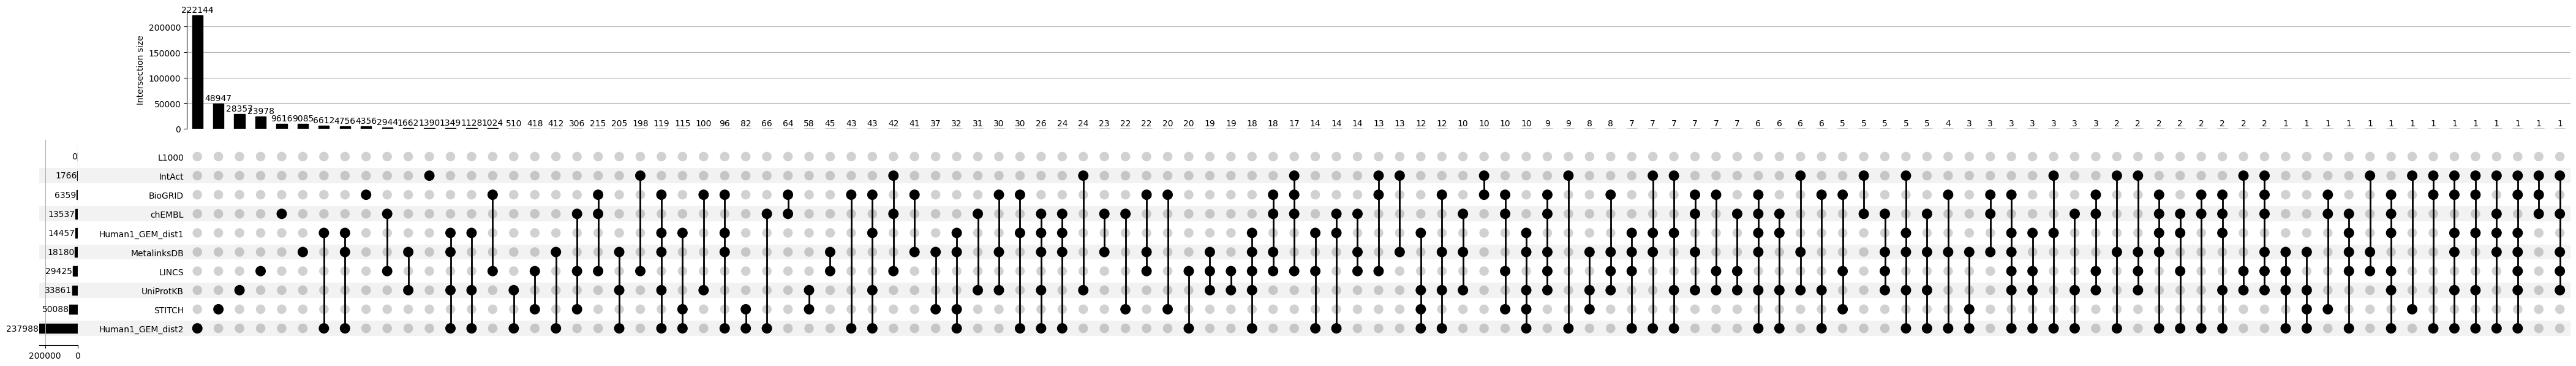

In [32]:
# Create UpSet plot to show the number of interactions per database

from upsetplot import UpSet
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create the dataframe for the upset plot
metabolite_gene_PKN_venn_data = metabolite_gene_PKN.copy()

# List of all databases to include
databases = ['IntAct', 'chEMBL', 'UniProtKB', 'STITCH', 'BioGRID', 'LINCS', 'L1000',
             'Human1_GEM_dist1', 'Human1_GEM_dist2', 'MetalinksDB']

# Subset to only include the databases of interest 
metabolite_gene_PKN_venn_data = metabolite_gene_PKN_venn_data[metabolite_gene_PKN_venn_data['Source'].isin(databases)]

# Group by 'Source' and create sets of unordered (Metabolite, Gene) pairs
source_groups = metabolite_gene_PKN_venn_data.groupby('Source').apply(
    lambda x: set(tuple(sorted(pair)) for pair in zip(x['Metabolite'], x['Gene']))
)

# Dynamically create sets for each database that exists in the data
database_sets = {}
for db in databases:
    if db in source_groups.index:
        database_sets[db] = source_groups[db]
    else:
        database_sets[db] = set()  # Empty set if database not found

# Create a list of all metabolite-gene pairs across all databases
all_pairs = list(set.union(*database_sets.values()) if database_sets.values() else set())

# Dynamically create the DataFrame columns
data_dict = {'Metabolite_Gene_Pair': all_pairs}
for db_name, db_set in database_sets.items():
    data_dict[db_name] = [1 if pair in db_set else 0 for pair in all_pairs]

# Create DataFrame
data = pd.DataFrame(data_dict)

# Prepare the DataFrame for the UpSet plot
data.set_index(list(database_sets.keys()), inplace=True)

# Create and display the UpSet plot
upset = UpSet(data.index.value_counts(), show_counts=True, sort_by='cardinality')
upset.plot()

# Save figure using configured output directory
figures_dir = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'metabolite_gene_PKN_interactionsPerDatabase.png'), dpi=600, bbox_inches='tight')

# Show plot
plt.show()


In [33]:
# read metabolite_gene_PKN
metabolite_gene_PKN = pd.read_csv(os.path.join(OUTPUT_DIR, 'metabolite_gene_PKN.tsv'), sep='\t')
metabolite_gene_PKN

,Metabolite,Gene,Source
0,1-Methylhistidine_HMDB0000001,ACTA1,BioGRID
1,"1,3-Diaminopropane_HMDB0000002",DHPS,UniProtKB
2,"1,3-Diaminopropane_HMDB0000002",DS,UniProtKB
3,"1,3-Diaminopropane_HMDB0000002",AOC1,Human1_GEM_dist1
4,"1,3-Diaminopropane_HMDB0000002",AOC2,Human1_GEM_dist1
...,...,...,...
405656,Glycerol 1-myristate_HMDB0304951,MOGAT2,UniProtKB
405657,Glycerol 1-myristate_HMDB0304951,DC5,UniProtKB
405658,Glycerol 1-myristate_HMDB0304951,DGAT2L5,UniProtKB
405659,Glycerol 1-myristate_HMDB0304951,ABHD12,UniProtKB


/tmp/ipykernel_47939/2015628554.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Database Interaction Summary:
Database                  Total     Unique     % Unique
Human1-GEM              237,988    228,756        96.1%
STITCH                   50,088     48,947        97.7%
UniProtKB                33,861     28,357        83.7%
LINCS                    29,425     23,978        81.5%
MetalinksDB              18,180      9,085        50.0%
chEMBL                   13,537      9,616        71.0%
BioGRID                   6,359      4,356        68.5%
IntAct                    1,766      1,390        78.7%

Figures saved to:
  PNG: /home/borisvdm/Documents/PhD/Lemonite/PKN/figures/database_interactions_proportion_unique.png
  PDF: /home/borisvdm/Documents/PhD/Lemonite/PKN/figures/database_interactions_proportion_unique.pdf


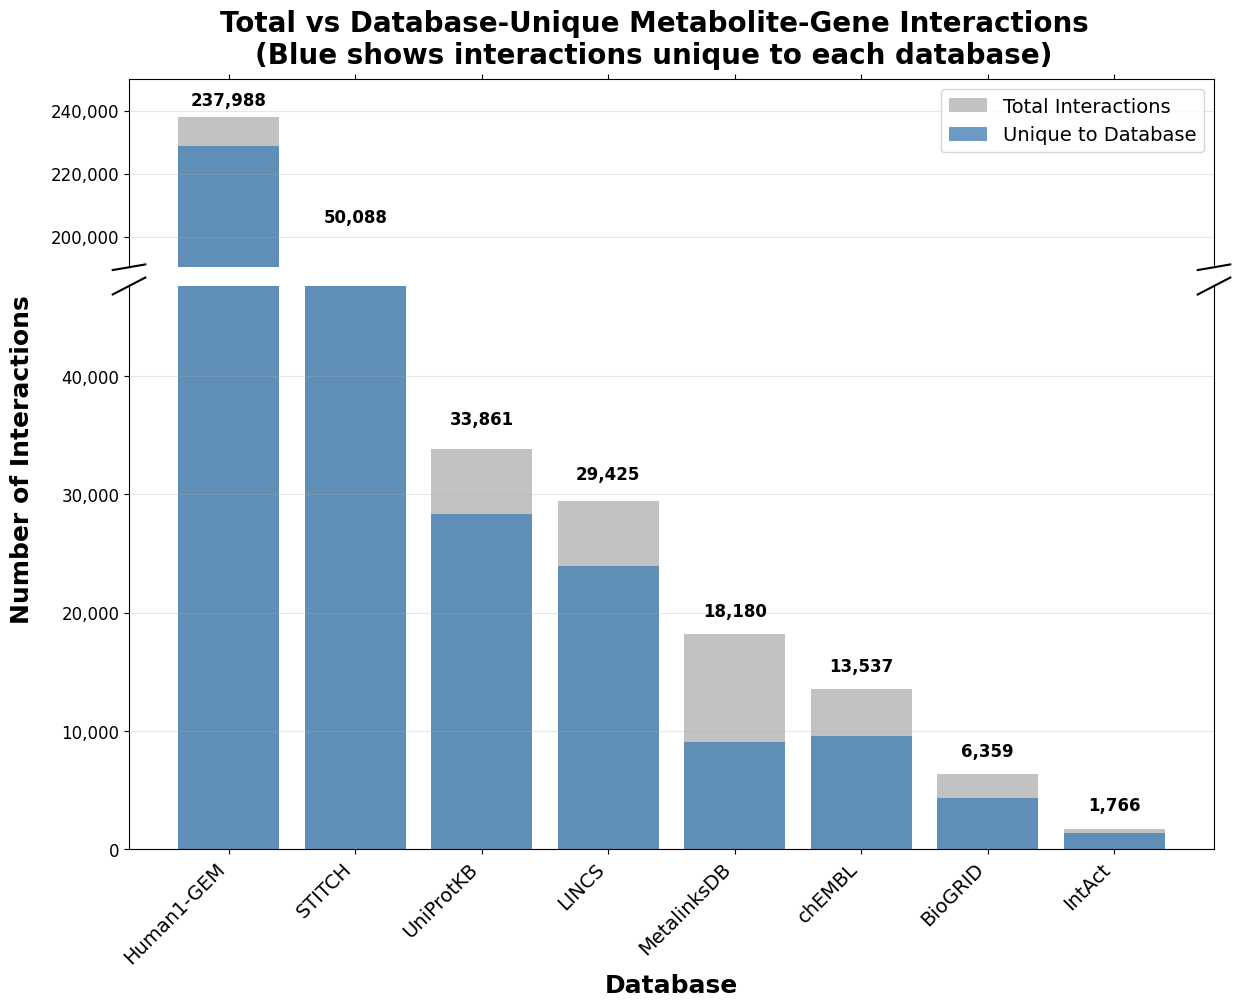

In [35]:
# Create barplot showing proportion of unique interactions per database
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

# Create a copy of the PKN data and merge Human1-GEM sources
metabolite_gene_PKN_plot = metabolite_gene_PKN.copy()
# Merge Human1_GEM_dist1 and Human1_GEM_dist2 into a single 'Human1-GEM' group
metabolite_gene_PKN_plot['Source'] = metabolite_gene_PKN_plot['Source'].replace({
    'Human1_GEM_dist1': 'Human1-GEM',
    'Human1_GEM_dist2': 'Human1-GEM'
})

# Define all databases with display names (Human1-GEM sources are now merged)
database_mapping = {
    'IntAct': 'IntAct',
    'BioGRID': 'BioGRID', 
    'chEMBL': 'chEMBL',
    'UniProtKB': 'UniProtKB',
    'STITCH': 'STITCH',
    'LINCS': 'LINCS',
    'L1000': 'L1000',
    'MetalinksDB': 'MetalinksDB',
    'Human1-GEM': 'Human1-GEM'
}

# Get databases that actually exist in the data
available_databases = metabolite_gene_PKN_plot['Source'].unique()
databases_to_plot = {k: v for k, v in database_mapping.items() if k in available_databases}

# Filter data for the databases of interest
databases_of_interest = list(databases_to_plot.keys())
filtered_data = metabolite_gene_PKN_plot[metabolite_gene_PKN_plot['Source'].isin(databases_of_interest)].copy()

# Create unique metabolite-gene pairs for each database
database_pairs = {}
total_interactions_count = {}

for source in databases_to_plot.keys():
    source_data = filtered_data[filtered_data['Source'] == source]
    # Get unique metabolite-gene pairs for this database
    unique_pairs = set(tuple(sorted([row['Metabolite'], row['Gene']])) 
                      for _, row in source_data[['Metabolite', 'Gene']].drop_duplicates().iterrows())
    database_pairs[source] = unique_pairs
    total_interactions_count[source] = len(unique_pairs)

# Find interactions that are unique to each database (not found in any other database)
unique_to_database = {}

for source in databases_to_plot.keys():
    # Get all pairs from other databases
    other_pairs = set()
    for other_source in databases_to_plot.keys():
        if other_source != source:
            other_pairs.update(database_pairs[other_source])
    
    # Find pairs that are unique to this database
    unique_pairs = database_pairs[source] - other_pairs
    unique_to_database[source] = len(unique_pairs)

# Create DataFrame for plotting
plot_data = pd.DataFrame({
    'Database': [databases_to_plot[db] for db in databases_to_plot.keys()],
    'Total_Interactions': [total_interactions_count[db] for db in databases_to_plot.keys()],
    'Unique_Interactions': [unique_to_database[db] for db in databases_to_plot.keys()]
})

# Calculate proportion of unique interactions
plot_data['Proportion_Unique'] = plot_data['Unique_Interactions'] / plot_data['Total_Interactions']

# Sort by total interactions (descending)
plot_data = plot_data.sort_values('Total_Interactions', ascending=False)

# Dynamically determine y-axis limits based on data
max_interactions = plot_data['Total_Interactions'].max()
has_large_values = max_interactions > 100000

if has_large_values and max_interactions > 200000:
    # Use broken axis if we have very large values
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05})
    
    # Plot on both axes
    for ax in [ax1, ax2]:
        # Create bars
        bars = ax.bar(range(len(plot_data)), plot_data['Total_Interactions'], 
                      color='darkgray', alpha=0.7, label='Total Interactions')
        
        # Fill bars according to unique interactions
        for i, (idx, row) in enumerate(plot_data.iterrows()):
            fill_height = row['Unique_Interactions']
            ax.bar(i, fill_height, color='steelblue', alpha=0.8)
    
    # Set y-axis limits dynamically
    upper_threshold = max_interactions * 0.8
    ax1.set_ylim(upper_threshold, max_interactions * 1.05)
    ax2.set_ylim(0, max_interactions * 0.2)
    
    # Hide the spines between ax1 and ax2
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)
    ax2.xaxis.tick_bottom()
    
    # Add break lines
    d = .015
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    
    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    
    # Labels and title
    ax2.set_xlabel('Database', fontsize=18, fontweight='bold')
    fig.text(0.04, 0.5, 'Number of Interactions', va='center', rotation='vertical', 
             fontsize=18, fontweight='bold')
    fig.suptitle('Total vs Database-Unique Metabolite-Gene Interactions\n(Blue shows interactions unique to each database)', 
                 fontsize=20, fontweight='bold', y=0.95)
    
    # Set x-axis labels
    ax2.set_xticks(range(len(plot_data)))
    ax2.set_xticklabels(plot_data['Database'], rotation=45, ha='right', fontsize=14)
    
    # Add value labels (total interactions only)
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        # Total interactions on top
        if row['Total_Interactions'] >= upper_threshold:
            label_ax = ax1
            y_offset = max_interactions * 0.01
        else:
            label_ax = ax2
            y_offset = max(row['Total_Interactions'] * 0.05, max_interactions * 0.005)
        
        label_ax.text(i, row['Total_Interactions'] + y_offset, 
                      f"{row['Total_Interactions']:,}", ha='center', va='bottom', 
                      fontweight='bold', fontsize=12)
    
    # Format y-axis
    for ax in [ax1, ax2]:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='y', labelsize=12)
    
    # Legend
    legend_elements = [
        Patch(facecolor='darkgray', alpha=0.7, label='Total Interactions'),
        Patch(facecolor='steelblue', alpha=0.8, label='Unique to Database')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=14)
    
else:
    # Use single axis for smaller datasets
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create bars
    bars = ax.bar(range(len(plot_data)), plot_data['Total_Interactions'], 
                  color='darkgray', alpha=0.7, label='Total Interactions')
    
    # Fill bars according to unique interactions
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        fill_height = row['Unique_Interactions']
        ax.bar(i, fill_height, color='steelblue', alpha=0.8)
    
    # Labels and title
    ax.set_xlabel('Database', fontsize=18, fontweight='bold')
    ax.set_ylabel('Number of Interactions', fontsize=18, fontweight='bold')
    ax.set_title('Total vs Database-Unique Metabolite-Gene Interactions\n(Blue shows interactions unique to each database)', 
                 fontsize=20, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(range(len(plot_data)))
    ax.set_xticklabels(plot_data['Database'], rotation=45, ha='right', fontsize=14)
    
    # Add value labels (total interactions only)
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        # Total interactions on top
        y_offset = max(row['Total_Interactions'] * 0.05, max_interactions * 0.01)
        ax.text(i, row['Total_Interactions'] + y_offset, 
                f"{row['Total_Interactions']:,}", ha='center', va='bottom', 
                fontweight='bold', fontsize=12)
    
    # Format y-axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=12)
    
    # Legend
    legend_elements = [
        Patch(facecolor='darkgray', alpha=0.7, label='Total Interactions'),
        Patch(facecolor='steelblue', alpha=0.8, label='Unique to Database')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=14)

plt.tight_layout()

# Print summary statistics
print("\nDatabase Interaction Summary:")
print("="*70)
print(f"{'Database':<20} {'Total':>10} {'Unique':>10} {'% Unique':>12}")
print("="*70)
for idx, row in plot_data.iterrows():
    print(f"{row['Database']:<20} {row['Total_Interactions']:>10,} {row['Unique_Interactions']:>10,} {row['Proportion_Unique']*100:>11.1f}%")
print("="*70)

# Save the plot using configured output directory
figures_dir = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(figures_dir, exist_ok=True)

png_path = os.path.join(figures_dir, 'database_interactions_proportion_unique.png')
pdf_path = os.path.join(figures_dir, 'database_interactions_proportion_unique.pdf')

plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, dpi=600, bbox_inches='tight')

print(f"\nFigures saved to:")
print(f"  PNG: {png_path}")
print(f"  PDF: {pdf_path}")

plt.show()